# Robust Predator–Prey Paper Analysis (v2)

This notebook preserves the original analysis and adds a separate, conservative workflow:

- three independent rollout-seed blocks;
- explicit 15-Hz biological time metadata (both sources use every second 30-fps frame);
- matched interaction-only biological initialization;
- explicit Couzin dynamics and checkpoint audit;
- corrected post-step wall reflection;
- hysteresis, target persistence, minimum duration, and cooldown for approach events;
- Kaplan–Meier response fractions under right censoring;
- equal-clip summaries and bootstrap confidence intervals;
- population-size **consistency/sensitivity**, not unseen-size generalization.

Rollout seeds quantify simulation variability for one trained checkpoint. They do not replace multiple training seeds.

Checkpoint compatibility is preserved: the learned state features and fixed locomotion speeds are not changed here. In the implementation, neighbor velocity is expressed in focal-heading axes but is not `v_neighbor - v_focal`; changing that representation would require retraining. The v2 rollout default does use corrected post-step wall reflection; set `WALL_MODE='legacy'` for an explicit sensitivity rerun against the training-era boundary behavior.


In [1]:
# Standard-library, numerical, plotting, and notebook-display imports.
from pathlib import Path
import hashlib, html, importlib, math, os, re, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython import get_ipython
from IPython.display import HTML, display
_ipython = get_ipython()
if _ipython is not None: _ipython.run_line_magic('matplotlib', 'inline')

# Resolve project paths whether the notebook starts in the project root or this folder.
ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis': ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
PROJECT_ROOT, NICOLE_ROOT = ANALYSIS_DIR.parent, ANALYSIS_DIR.parent / 'Nicole' / 'Predator-Prey-Thesis'
BIO_WINDOW_ROOT = NICOLE_ROOT / 'Data/1. Data Processing/Processed/video/expert_tensors/windows'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'

# Import the local analysis helpers without changing either source repository.
if str(ANALYSIS_DIR) not in sys.path: sys.path.insert(0, str(ANALYSIS_DIR))
import paper_analysis2 as pa
pa = importlib.reload(pa)  # pick up helper fixes in an already-running kernel

## Configuration

This section contains the small set of global analysis choices. Thresholds and risk bins are shared across every source, policy, and group size so comparisons use identical definitions.

In [2]:
# Tensor execution settings.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32

# Both biological sources retain every second frame from 30-fps recordings.
RAW_VIDEO_FPS, BIO_SAMPLING_STRIDE = 30.0, 2
EFFECTIVE_VIDEO_FPS = RAW_VIDEO_FPS / BIO_SAMPLING_STRIDE
STEP_DURATION = {'couzin': 0.5, 'biological': 1.0 / EFFECTIVE_VIDEO_FPS}

# Robust shared approach definition. Hysteresis and cooldown prevent overlapping
# events caused by closing-sign flicker; target persistence prevents proxy switches.
APPROACH_DISTANCE_THRESHOLD, APPROACH_EXIT_THRESHOLD = 0.15, 0.165
APPROACH_CLOSING_LAG, APPROACH_MIN_DURATION = 3, 2
CLOSING_SPEED_LAG = 3
RESPONSE_THRESHOLD = 0.10
RESPONSE_THRESHOLD_SENSITIVITY = (0.075, 0.10, 0.125)
RESPONSE_WINDOW_STEPS = {'couzin': 20, 'biological': 20}
APPROACH_COOLDOWN_STEPS = RESPONSE_WINDOW_STEPS
RESPONSE_LAG, TIME_CHUNK_SIZE = 1, 4096

# Fixed historical ranges retain comparability with v1. Unlike v1, v2 retains
# raw distances and reports the exact observations excluded by these ranges.
RISK_RANGES = {'couzin':(0.0144023038,0.2365715653),'biological':(0.0076781777,0.3913621008)}
N_DISTANCE_BINS = int(os.getenv('PAPER_ANALYSIS_N_DISTANCE_BINS', '6'))
MIN_SAMPLES_PER_BIN = int(os.getenv('PAPER_ANALYSIS_MIN_SAMPLES_PER_BIN', '30'))
MIN_CLIPS_PER_BIN = int(os.getenv('PAPER_ANALYSIS_MIN_CLIPS_PER_BIN', '5'))
N_BOOTSTRAP, CI_LEVEL = int(os.getenv('PAPER_ANALYSIS_N_BOOTSTRAP', '1000')), 0.95
RISK_BIN_EDGES = {source:torch.linspace(low,high,N_DISTANCE_BINS+1,device=DEVICE,dtype=DTYPE) for source,(low,high) in RISK_RANGES.items()}
D_SOURCE = {'couzin': math.hypot(50, 50), 'biological': math.hypot(2160, 2160)}

# Each block contains independent rollout seeds. Total rollouts per simulated
# case are len(ROLLOUT_SEEDS) * N_ROLLOUTS_PER_SEED.
ROLLOUT_SEEDS = tuple(int(value) for value in os.getenv('PAPER_ANALYSIS_ROLLOUT_SEEDS', '2027,12027,22027').split(','))
N_ROLLOUTS_PER_SEED = int(os.getenv('PAPER_ANALYSIS_N_ROLLOUTS_PER_SEED', '10'))
ROLLOUT_STEPS = int(os.getenv('PAPER_ANALYSIS_ROLLOUT_STEPS', '1000'))
WALL_MODE = 'post_step_reflect'
SAVE_RESULTS = False

ANALYSIS_SIGNATURE = {
 'version':'v2_robust','biological_effective_fps':EFFECTIVE_VIDEO_FPS,
 'biological_sampling_stride':BIO_SAMPLING_STRIDE,
 'approach_threshold':APPROACH_DISTANCE_THRESHOLD,'approach_exit_threshold':APPROACH_EXIT_THRESHOLD,
 'approach_lag':APPROACH_CLOSING_LAG,'approach_min_duration':APPROACH_MIN_DURATION,
 'approach_cooldown_steps':APPROACH_COOLDOWN_STEPS,'target_persistence':True,
 'closing_lag':CLOSING_SPEED_LAG,'response_threshold':RESPONSE_THRESHOLD,
 'response_threshold_sensitivity':RESPONSE_THRESHOLD_SENSITIVITY,
 'response_window_transitions':RESPONSE_WINDOW_STEPS,'censoring':'Kaplan-Meier by event; equal-clip primary summaries',
 'risk_curve_estimand':'clip_balanced','n_bins':N_DISTANCE_BINS,
 'min_samples':MIN_SAMPLES_PER_BIN,'min_clips':MIN_CLIPS_PER_BIN,
 'risk_ranges':RISK_RANGES,'rollout_seed_blocks':ROLLOUT_SEEDS,
 'rollouts_per_seed':N_ROLLOUTS_PER_SEED,'wall_mode':WALL_MODE,
 'population_size_claim':'consistency/sensitivity within trained sizes'}
display(ANALYSIS_SIGNATURE)


{'version': 'v2_robust',
 'biological_effective_fps': 15.0,
 'biological_sampling_stride': 2,
 'approach_threshold': 0.15,
 'approach_exit_threshold': 0.165,
 'approach_lag': 3,
 'approach_min_duration': 2,
 'approach_cooldown_steps': {'couzin': 20, 'biological': 20},
 'target_persistence': True,
 'closing_lag': 3,
 'response_threshold': 0.1,
 'response_threshold_sensitivity': (0.075, 0.1, 0.125),
 'response_window_transitions': {'couzin': 20, 'biological': 20},
 'censoring': 'Kaplan-Meier by event; equal-clip primary summaries',
 'risk_curve_estimand': 'clip_balanced',
 'n_bins': 6,
 'min_samples': 30,
 'min_clips': 5,
 'risk_ranges': {'couzin': (0.0144023038, 0.2365715653),
  'biological': (0.0076781777, 0.3913621008)},
 'rollout_seed_blocks': (2027, 12027, 22027),
 'rollouts_per_seed': 10,
 'wall_mode': 'post_step_reflect',
 'population_size_claim': 'consistency/sensitivity within trained sizes'}

## Load or generate all cases once
`D_source` is the declared arena diagonal, never an observed trajectory maximum. Nearest prey is recomputed every frame and is only a target proxy.

There is no continuous Biological-16 expert trajectory. The `bio_expert_16` case is nevertheless included in the analysis by reconstructing trajectories from hand-labelled interaction windows with `load_biological_window_trajectories(...)`. This window-based source is methodologically not identical to the continuous Biological-32 expert pipeline.

In [3]:
# Checkpoint and environment settings for the Couzin-trained policy pair.
COUZIN_POLICY = {
 'root': NICOLE_ROOT, 'code_subdir': '.',
 'prey_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint': 'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features': 6, 'pred_features': 5, 'deterministic': False,
 'environment': {'area_width':50,'area_height':50,'prey_speed':5,'pred_speed':5,'step_size':0.5,'max_turn':0.25,'max_speed_norm':5.0}}

# This manifest is explicit because the available checkpoint predates the
# current curriculum notebook. Adjust it here if the archived training config
# proves different; the audit below prevents internally inconsistent values.
COUZIN_DYNAMICS = {
 'dt':0.5, 'alpha':0.1, 'theta_dot_max':0.5, 'theta_dot_max_shark':0.5,
 'constant_speed':5.0, 'shark_speed':5.0}
expected_turn = COUZIN_DYNAMICS['dt'] * COUZIN_DYNAMICS['theta_dot_max']
assert math.isclose(COUZIN_POLICY['environment']['step_size'], COUZIN_DYNAMICS['dt'])
assert math.isclose(COUZIN_POLICY['environment']['max_turn'], expected_turn)
ANALYSIS_SIGNATURE['couzin_dynamics'] = dict(COUZIN_DYNAMICS)

def _checkpoint_record(policy,key):
 path=(policy['root']/policy[key]).resolve()
 if not path.is_file(): return {'path':str(path),'available':False}
 digest=hashlib.sha256()
 with path.open('rb') as handle:
  for chunk in iter(lambda:handle.read(1024*1024),b''): digest.update(chunk)
 return {'path':str(path),'available':True,'bytes':path.stat().st_size,'sha256':digest.hexdigest()}

BIO_POLICY = {
 'root': NICOLE_ROOT, 'code_subdir': '.',
 'prey_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint': 'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features': 6, 'pred_features': 5, 'deterministic': False,
 'environment': {'area_width':2160,'area_height':2160,'prey_speed':10,'pred_speed':10,'step_size':1.0,'max_turn':0.314,'max_speed_norm':25.0}}

ANALYSIS_SIGNATURE['policy_environments'] = {'couzin':dict(COUZIN_POLICY['environment']),'biological':dict(BIO_POLICY['environment'])}
BIO_EXPERT_ROOT_32 = NICOLE_ROOT / 'Data/1. Data Processing/Processed/video/expert_tensors/32_prey_interactions/2. filtered_frames'
INIT_POOL_PATHS = {n: NICOLE_ROOT / f'Data/1. Data Processing/Processed/init_pool/init_pool_{n}prey.pt' for n in (16,32)}
# Verified construction order from 2.2 Create Initial Position Pool.ipynb.
INIT_POOL_PARTITIONS = {16:{'interaction':(0,1619),'attack':(1619,3293)},32:{'interaction':(0,24),'attack':(24,1081)}}

def _load_tensor(path):
 try: return torch.load(path,map_location='cpu',weights_only=True)
 except (TypeError,RuntimeError): return torch.load(path,map_location='cpu')

BIO_INTERACTION_POOLS = {}
for n,path in INIT_POOL_PATHS.items():
 pool = _load_tensor(path)
 start,stop = INIT_POOL_PARTITIONS[n]['interaction']
 assert tuple(pool.shape[1:]) == (n+1,3) and len(pool) == INIT_POOL_PARTITIONS[n]['attack'][1]
 BIO_INTERACTION_POOLS[n] = pool[start:stop].clone()

case_specs = {
 **{f'couzin_expert_{n}': {'source':'couzin','kind':'couzin_expert','n_prey':n} for n in (16,32)},
 **{f'couzin_imitation_{n}': {'source':'couzin','kind':'imitation','n_prey':n,'policy':COUZIN_POLICY} for n in (16,32)},
 **{f'bio_expert_{n}': {'source':'biological','kind':'bio_expert','n_prey':n} for n in (16,32)},
 **{f'bio_imitation_{n}': {'source':'biological','kind':'imitation','n_prey':n,'policy':BIO_POLICY} for n in (16,32)}}

cases, skipped_cases, case_diagnostics = {}, {}, {}
for name,spec in tqdm(case_specs.items(),desc='Loading/generating robust-v2 cases'):
 n,source = spec['n_prey'],spec['source']
 expert_source = BIO_WINDOW_ROOT if n == 16 else BIO_EXPERT_ROOT_32
 if spec['kind'] == 'bio_expert' and not expert_source.is_dir():
  skipped_cases[name] = f'Biological expert source is missing: {expert_source}'; continue
 try:
  if spec['kind'] == 'couzin_expert':
   table = pa.generate_couzin_expert_rollouts(
    NICOLE_ROOT,n_prey=n,n_rollouts=N_ROLLOUTS_PER_SEED,rollout_steps=ROLLOUT_STEPS,
    seed=ROLLOUT_SEEDS[0],rollout_seeds=ROLLOUT_SEEDS,area_width=50,area_height=50,
    wall_mode=WALL_MODE,**COUZIN_DYNAMICS)
  elif spec['kind'] == 'bio_expert' and n == 16:
   table = pa.load_biological_window_trajectories(
    BIO_WINDOW_ROOT,n_prey=16,condition='interaction',coordinate_scale=2160,
    effective_fps=EFFECTIVE_VIDEO_FPS,sampling_stride=BIO_SAMPLING_STRIDE)
  elif spec['kind'] == 'bio_expert':
   table = pa.load_expert_trajectories(
    BIO_EXPERT_ROOT_32,n_prey=32,condition='interaction',image_y_down=True,
    coordinate_height=2160,role_map={'1':'predator','2':'prey'},
    require_complete_frames=True,fps=EFFECTIVE_VIDEO_FPS)
   table = pa.with_constant_metadata(
    table,fps=EFFECTIVE_VIDEO_FPS,step_duration=STEP_DURATION['biological'],sampling_stride=BIO_SAMPLING_STRIDE)
  else:
   config = spec['policy']
   init_pool = (pa.initial_state_pool_from_trajectory(cases[f'couzin_expert_{n}'],expected_n_prey=n)
                if source == 'couzin' else BIO_INTERACTION_POOLS[n])
   table = pa.generate_policy_rollouts(
    config,config['root'],n_prey=n,n_rollouts=N_ROLLOUTS_PER_SEED,
    rollout_steps=ROLLOUT_STEPS,seed=ROLLOUT_SEEDS[0],rollout_seeds=ROLLOUT_SEEDS,
    init_pool_tensor=init_pool,condition='interaction' if source == 'biological' else 'approach',
    effective_fps=EFFECTIVE_VIDEO_FPS if source == 'biological' else None,
    sampling_stride=BIO_SAMPLING_STRIDE if source == 'biological' else 1,
    wall_mode=WALL_MODE)
 except (FileNotFoundError,pa.ExpertDataUnavailable) as exc:
  skipped_cases[name] = str(exc); continue

 diag = pa.trajectory_diagnostics(table)
 if diag['prey_per_frame_min'] != n or diag['prey_per_frame_max'] != n:
  raise ValueError(f'{name}: expected exactly {n} prey in every frame, got {diag}')
 if not np.all(np.isfinite(table['x'])) or not np.all(np.isfinite(table['y'])) or not np.all(np.isfinite(table['heading'])):
  raise ValueError(f'{name}: non-finite position or heading detected')
 cases[name],case_diagnostics[name] = table,diag

checkpoint_manifest={name:{key:_checkpoint_record(policy,key) for key in ('prey_checkpoint','pred_checkpoint')} for name,policy in {'couzin':COUZIN_POLICY,'biological':BIO_POLICY}.items()}
display({'available_cases':sorted(cases),'skipped_cases':skipped_cases,
         'biological_interaction_pool_sizes':{n:len(v) for n,v in BIO_INTERACTION_POOLS.items()},
         'couzin_checkpoint_manifest_assumption':COUZIN_DYNAMICS,'checkpoint_manifest':checkpoint_manifest})
display(case_diagnostics)


Loading/generating robust-v2 cases: 100%|██████████| 8/8 [15:38<00:00, 117.35s/it]


{'available_cases': ['bio_expert_16',
  'bio_expert_32',
  'bio_imitation_16',
  'bio_imitation_32',
  'couzin_expert_16',
  'couzin_expert_32',
  'couzin_imitation_16',
  'couzin_imitation_32'],
 'skipped_cases': {},
 'biological_interaction_pool_sizes': {16: 1619, 32: 24},
 'couzin_checkpoint_manifest_assumption': {'dt': 0.5,
  'alpha': 0.1,
  'theta_dot_max': 0.5,
  'theta_dot_max_shark': 0.5,
  'constant_speed': 5.0,
  'shark_speed': 5.0},
 'checkpoint_manifest': {'couzin': {'prey_checkpoint': {'path': 'C:\\Users\\janni\\OneDrive\\Dokumente\\Privat\\Bildung\\M. Sc. Social and Economic Data Science\\Thesis Paper\\ICRA2027-PredatorPreyGAIL\\Nicole\\Predator-Prey-Thesis\\Data\\2. Training\\CouzinPredPrey - GAIL\\stage1_seed42_32and16\\prey_policy_stage1.pth',
    'available': True,
    'bytes': 96229,
    'sha256': 'd2e306857c8d1922a831047ae52b24cf8bf1ef54007c16971e886a622086636d'},
   'pred_checkpoint': {'path': 'C:\\Users\\janni\\OneDrive\\Dokumente\\Privat\\Bildung\\M. Sc. Social a

{'couzin_expert_16': {'rows': 510000,
  'clips_or_rollouts': 30,
  'frames': 30000,
  'prey_per_frame_min': 16,
  'prey_per_frame_max': 16,
  'x_range': (0.0, 50.0),
  'y_range': (0.0, 50.0),
  'heading_range': (-3.141592653589793, 3.1415734400929516),
  'conditions': {np.str_('approach'): 510000},
  'fps_values': [],
  'step_duration_values': [0.5],
  'rollout_replicate_seeds': [2027, 12027, 22027],
  'independent_simulation_seeds': 30,
  'wall_modes': ['post_step_reflect'],
  'timestep_status': 'explicit step duration'},
 'couzin_expert_32': {'rows': 990000,
  'clips_or_rollouts': 30,
  'frames': 30000,
  'prey_per_frame_min': 32,
  'prey_per_frame_max': 32,
  'x_range': (0.0, 50.0),
  'y_range': (0.0, 50.0),
  'heading_range': (-3.141592653589793, 3.1415866168658075),
  'conditions': {np.str_('approach'): 990000},
  'fps_values': [],
  'step_duration_values': [0.5],
  'rollout_replicate_seeds': [2027, 12027, 22027],
  'independent_simulation_seeds': 30,
  'wall_modes': ['post_step_r

In [4]:
# Run the complete robust metric suite once for every available case.
case_results = {}
with torch.inference_mode():
 for name,table in tqdm(cases.items(),desc='Analyzing robust-v2 cases'):
  source = case_specs[name]['source']
  case_results[name] = pa.analyze_case(
   table,d_source=D_SOURCE[source],risk_bin_edges=RISK_BIN_EDGES[source],
   expected_n_prey=case_specs[name]['n_prey'],device=DEVICE,dtype=DTYPE,
   time_chunk_size=TIME_CHUNK_SIZE,approach_distance_threshold=APPROACH_DISTANCE_THRESHOLD,
   approach_exit_threshold=APPROACH_EXIT_THRESHOLD,approach_closing_lag=APPROACH_CLOSING_LAG,
   approach_min_duration=APPROACH_MIN_DURATION,
   approach_cooldown_steps=APPROACH_COOLDOWN_STEPS[source],require_target_persistence=True,
   closing_speed_lag=CLOSING_SPEED_LAG,response_threshold=RESPONSE_THRESHOLD,
   response_threshold_sensitivity=RESPONSE_THRESHOLD_SENSITIVITY,
   response_window_steps=RESPONSE_WINDOW_STEPS[source],response_lag=RESPONSE_LAG,
   min_bin_count=MIN_SAMPLES_PER_BIN,min_cluster_count=MIN_CLIPS_PER_BIN,
   n_bootstrap=N_BOOTSTRAP,ci_level=CI_LEVEL,bootstrap_seed=ROLLOUT_SEEDS[0],
   step_duration=STEP_DURATION[source])

group_size_results = pa.compute_all_group_size_comparisons(case_results)
results = {}
for metric in ('closing_speed','pursuit_alignment','escape_alignment','risk_conditioned_nnd','risk_conditioned_polarization','continuous_predator_response_curve'):
 results[metric] = {name:r['curves'][metric] for name,r in case_results.items()}
for metric in next(iter(case_results.values()))['aggregate'] if case_results else ():
 results.setdefault(metric,{}).update({name:r['aggregate'][metric] for name,r in case_results.items()})
for key in ('events','response_availability','predator_distance_raw','predator_distance_normalized','diagnostics','response_threshold_sensitivity'):
 results[key] = {name:r[key] for name,r in case_results.items()}
results['group_size_consistency'] = group_size_results
results['analysis_signature'] = ANALYSIS_SIGNATURE
results['checkpoint_manifest'] = checkpoint_manifest

# Independent rollout-seed block summaries. These expose seed sensitivity of
# one checkpoint without mislabelling it as training-seed uncertainty.
rollout_seed_rows = []
for name,r in case_results.items():
 clip_ids = r['clip_ids']
 parsed = [int(m.group(1)) if (m:=re.match(r'seed_(\d+)_',clip_id)) else None for clip_id in clip_ids]
 if not any(seed is not None for seed in parsed): continue
 for metric,values in r['per_clip'].items():
  for seed in ROLLOUT_SEEDS:
   idx = [i for i,value in enumerate(parsed) if value == seed]
   if not idx: continue
   selected = values[torch.as_tensor(idx,device=values.device)]
   selected = selected[torch.isfinite(selected)]
   rollout_seed_rows.append({'case':name,'metric':metric,'rollout_seed_block':seed,
                             'rollouts':len(selected),'mean':float(selected.mean()) if len(selected) else np.nan,
                             'std_across_rollouts':float(selected.std(unbiased=False)) if len(selected) else np.nan})
results['rollout_seed_summaries'] = rollout_seed_rows

display([{'case':name,**r['diagnostics']} for name,r in case_results.items()])
display({'sanity_tests':pa.run_geometry_sanity_tests(),
         'important':'Rollout-seed blocks do not quantify retraining uncertainty.'})

if SAVE_RESULTS:
 OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
 torch.save(results,OUTPUT_DIR/'predator_prey_metrics_v2.pt')


Analyzing robust-v2 cases: 100%|██████████| 8/8 [03:47<00:00, 28.41s/it]


[{'case': 'couzin_expert_16',
  'valid_frames': 30000,
  'invalid_frames': 0,
  'frame_clips': 30,
  'frame_level_segments': 30,
  'temporal_segments': 30,
  'response_segments': 30,
  'response_capable_segments': 30,
  'expected_source_timestep_delta': 1.0,
  'approach_events': 69,
  'response_approach_events': 69,
  'responding_events': 69,
  'total_approach_events': 69,
  'valid_propagation_events': 68,
  'fraction_valid_propagation_events': 0.9855072463768116},
 {'case': 'couzin_expert_32',
  'valid_frames': 30000,
  'invalid_frames': 0,
  'frame_clips': 30,
  'frame_level_segments': 30,
  'temporal_segments': 30,
  'response_segments': 30,
  'response_capable_segments': 30,
  'expected_source_timestep_delta': 1.0,
  'approach_events': 65,
  'response_approach_events': 65,
  'responding_events': 65,
  'total_approach_events': 65,
  'valid_propagation_events': 65,
  'fraction_valid_propagation_events': 1.0},
 {'case': 'couzin_imitation_16',
  'valid_frames': 30000,
  'invalid_frames

{'sanity_tests': {'wrap_pi': True,
  'predator_ahead': True,
  'predator_left': True,
  'predator_right': True,
  'left_turn_positive': True,
  'right_turn_negative': True,
  'polarization_aligned': True,
  'polarization_opposed': True,
  'known_nnd': True,
  'closer_risk_distance': True,
  'away_response_positive': True,
  'km_handles_censoring': True,
  'approach_hysteresis_prevents_flicker': True},
 'important': 'Rollout-seed blocks do not quantify retraining uncertainty.'}

In [5]:
# Shared visual language: source panels, expert/imitation colors, and group-size shades.
COLORS={'expert_16':'#1f77b4','expert_32':'#0b3c6f','imitation_16':'#ff8c42','imitation_32':'#c44e00'}
def _style(name):
 return ('couzin' if name.startswith('couzin') else 'biological'), next(x for x in COLORS if x in name)

# Two-panel helper for all risk-conditioned curve metrics.
def plot_curve(metric,ylabel,xlabel='Normalized predator-to-nearest-prey distance'):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name)
   if src!=source: continue
   c=r['curves'][metric]; x=c['bin_center'].cpu(); balanced=c['clip_balanced_mean'].cpu()
   label=style.replace('_',' ').title(); ax.plot(x,balanced,marker='o',ms=3,color=COLORS[style],label=label); ax.fill_between(x,c['clip_balanced_ci_low'].cpu(),c['clip_balanced_ci_high'].cpu(),color=COLORS[style],alpha=.12)
  ax.set(title=source.title(),xlabel=xlabel,ylabel=ylabel,xlim=RISK_RANGES[source]); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show(); plt.close(fig)

# Distribution helper for per-clip scalars or per-event observations.
def plot_scalar(metric,ylabel,event=False):
 names,data=[],[]
 for name,r in case_results.items():
  v=r['events'].get(metric) if event else r['per_clip'].get(metric)
  if v is not None and v.numel(): names.append(name.replace('_','\n')); data.append(v.cpu().numpy())
 if data:
  fig,ax=plt.subplots(figsize=(max(8,1.2*len(data)),4)); ax.boxplot(data,tick_labels=names,showfliers=False); ax.set_ylabel(ylabel); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show(); plt.close(fig)

# Event-relative helper for NND and polarization changes after approach onset.
def plot_event(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name); valid=[x for x in r[key] if x.numel()]
   if src==source and valid:
    v=torch.cat(valid).cpu(); ax.plot(torch.arange(v.shape[1]),torch.nanmean(v,0),color=COLORS[style],label=style.replace('_',' ').title())
  ax.axhline(0,color='.4',lw=.8); ax.set(title=source.title(),xlabel='Steps since approach onset',ylabel=ylabel); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show(); plt.close(fig)

# Whole-sequence helper for DoS and DoA time evolution.
def plot_timeline(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name); series=r[key]; length=max((len(x) for x in series),default=0)
   if src==source and length:
    padded=torch.full((len(series),length),torch.nan,device=series[0].device,dtype=series[0].dtype)
    for i,x in enumerate(series): padded[i,:len(x)]=x
    ax.plot(torch.nanmean(padded,0).cpu(),color=COLORS[style],label=style.replace('_',' ').title())
  ax.set(title=source.title(),xlabel='Sample index (biological: 15 Hz; Couzin: dt=0.5)',ylabel=ylabel); ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show(); plt.close(fig)

# Numerical outputs mirror every plot and remain available for later use.
numerical_outputs = {}

# Lightweight HTML-table formatting avoids a separate pandas pipeline.
def _format_table_value(value):
 if torch.is_tensor(value) and value.numel()==1: value=value.item()
 if isinstance(value,(float,np.floating)):
  return 'NaN' if not np.isfinite(value) else f'{value:.8g}'
 return str(value)
def display_table(rows,title,max_height=420):
 if not rows:
  display(HTML(f'<h4>{html.escape(title)}</h4><em>No valid values.</em>')); return
 columns=list(rows[0]); head=''.join(f'<th>{html.escape(str(c))}</th>' for c in columns)
 body=''.join('<tr>'+''.join(f'<td>{html.escape(_format_table_value(row.get(c,"")))}</td>' for c in columns)+'</tr>' for row in rows)
 style='border-collapse:collapse;width:100%;font-size:12px;text-align:right'
 display(HTML(f'<style>.metric-table th,.metric-table td{{padding:5px 9px;border-bottom:1px solid #eee;white-space:nowrap}}.metric-table th{{text-align:right}}</style><h4>{html.escape(title)}</h4><div style="max-height:{max_height}px;overflow:auto;border:1px solid #ddd"><table class="metric-table" style="{style}"><thead style="position:sticky;top:0;background:white"><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>'))

# Table builders for curves, distributions, event profiles, and timelines.
def show_curve_values(metric):
 out,rows={},[]
 for name,r in case_results.items():
  fields=('bin_center','sample_weighted_mean','sample_weighted_ci_low','sample_weighted_ci_high','clip_balanced_mean','clip_balanced_ci_low','clip_balanced_ci_high','count','cluster_count','supported')
  c={k:r['curves'][metric][k].detach().cpu().tolist() for k in fields}; out[name]=c
  rows.extend({'case':name,'bin':i,'distance':c['bin_center'][i],'sample_weighted_mean':c['sample_weighted_mean'][i],'sample_ci_low':c['sample_weighted_ci_low'][i],'sample_ci_high':c['sample_weighted_ci_high'][i],'clip_balanced_mean':c['clip_balanced_mean'][i],'clip_ci_low':c['clip_balanced_ci_low'][i],'clip_ci_high':c['clip_balanced_ci_high'][i],'n':c['count'][i],'clusters':c['cluster_count'][i],'supported':c['supported'][i]} for i in range(len(c['bin_center'])))
 numerical_outputs[metric]=out; display_table(rows,f'{metric}: risk-conditioned values'); return out
def show_distribution_values(metric,event=False):
 full,summary,rows={},{},[]
 for name,r in case_results.items():
  v=r['events'].get(metric) if event else r['per_clip'].get(metric)
  if v is None: continue
  v=v.detach().float().cpu(); v=v[torch.isfinite(v)]; full[name]=v
  valid_clips=int(torch.isfinite(r['per_clip'][metric]).sum()) if metric in r['per_clip'] else np.nan
  s={'case':name,'n':len(v),'valid_clips':valid_clips,'mean':float(v.mean()) if len(v) else np.nan,'std':float(v.std(unbiased=False)) if len(v) else np.nan,'median':float(v.median()) if len(v) else np.nan,'q25':float(torch.quantile(v,.25)) if len(v) else np.nan,'q75':float(torch.quantile(v,.75)) if len(v) else np.nan,'min':float(v.min()) if len(v) else np.nan,'max':float(v.max()) if len(v) else np.nan}; summary[name]={k:x for k,x in s.items() if k!='case'}; rows.append(s)
 numerical_outputs[metric]={'summary':summary,'values':full}; display_table(rows,f'{metric}: numerical summary'); return summary
def show_event_profile_values(key):
 out,rows={},[]
 for name,r in case_results.items():
  valid=[x.detach().cpu() for x in r[key] if x.numel()]
  if not valid: continue
  v=torch.cat(valid); mean=torch.nanmean(v,0); std=torch.nanmean((v-mean)**2,0).sqrt(); count=torch.isfinite(v).sum(0); out[name]={'step':list(range(v.shape[1])),'mean':mean.tolist(),'std':std.tolist(),'count':count.tolist()}
  rows.extend({'case':name,'step':step,'mean':mean[step].item(),'std':std[step].item(),'n':count[step].item()} for step in range(v.shape[1]))
 numerical_outputs[key]=out; display_table(rows,f'{key}: event-relative values'); return out
def show_timeline_values(key,aggregate_metric):
 full,summary,summary_rows,timeline_rows={},{},[],[]
 for name,r in case_results.items():
  length=max((len(x) for x in r[key]),default=0)
  if not length: continue
  timeline=torch.full((len(r[key]),length),torch.nan,device=r[key][0].device,dtype=r[key][0].dtype)
  for i,x in enumerate(r[key]): timeline[i,:len(x)]=x
  timeline=timeline.detach().cpu(); mean_timeline=torch.nanmean(timeline,0); timeline_count=torch.isfinite(timeline).sum(0); aggregate=r['per_clip'][aggregate_metric].detach().cpu(); full[name]={'mean_timeline':mean_timeline,'timeline_count':timeline_count,'per_clip_aggregate':aggregate}
  s={'case':name,'steps':length,'clips':len(timeline),'aggregate_mean':float(aggregate.mean()),'aggregate_std':float(aggregate.std(unbiased=False))}; summary[name]={k:x for k,x in s.items() if k!='case'}; summary_rows.append(s)
  timeline_rows.extend({'case':name,'step':step,'mean':mean_timeline[step].item(),'clips':timeline_count[step].item()} for step in range(length))
 numerical_outputs[aggregate_metric]={'summary':summary,'values':full}; display_table(summary_rows,f'{aggregate_metric}: aggregate values'); display_table(timeline_rows,f'{aggregate_metric}: mean time evolution'); return summary


# ---- robust-v2 plotting and numerical-summary overrides ----
def plot_scalar(metric,ylabel,event=False):
 names,data=[],[]
 for name,r in case_results.items():
  values = r['events'].get(metric) if event else r['per_clip'].get(metric)
  if values is None: continue
  values=values.detach().float().cpu(); values=values[torch.isfinite(values)]
  if len(values): names.append(name.replace('_','\n')); data.append(values.numpy())
 if data:
  fig,ax=plt.subplots(figsize=(max(8,1.2*len(data)),4)); ax.boxplot(data,tick_labels=names,showfliers=False)
  ax.set_ylabel(ylabel); ax.set_title('Per-event diagnostic' if event else 'Primary equal-clip distribution')
  ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show(); plt.close(fig)

def plot_event(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  for name,r in case_results.items():
   src,style=_style(name)
   if src!=source: continue
   matrix=r.get(f'{key}_per_clip')
   if matrix is None or not matrix.numel(): continue
   summary=pa.bootstrap_clip_mean(matrix,n_bootstrap=N_BOOTSTRAP,ci_level=CI_LEVEL,seed=ROLLOUT_SEEDS[0])
   x=torch.arange(matrix.shape[1]).cpu(); mean=summary['mean'].cpu()
   ax.plot(x,mean,color=COLORS[style],label=style.replace('_',' ').title())
   ax.fill_between(x,summary['ci_low'].cpu(),summary['ci_high'].cpu(),color=COLORS[style],alpha=.12)
  ax.axhline(0,color='.4',lw=.8); ax.set(title=source.title(),xlabel='Steps since robust approach onset',ylabel=ylabel)
  ax.grid(alpha=.25); handles,labels=ax.get_legend_handles_labels(); ax.legend(handles,labels,frameon=False) if handles else None
 fig.tight_layout(); plt.show(); plt.close(fig)

def show_distribution_values(metric,event=False):
 full,summary,rows={},{},[]
 for name,r in case_results.items():
  values=r['events'].get(metric) if event else r['per_clip'].get(metric)
  if values is None: continue
  values=values.detach().float().cpu(); values=values[torch.isfinite(values)]; full[name]=values
  boot=pa.bootstrap_clip_mean(values,n_bootstrap=N_BOOTSTRAP if not event else 0,ci_level=CI_LEVEL,seed=ROLLOUT_SEEDS[0]) if len(values) else None
  row={'case':name,'unit':'event (diagnostic)' if event else 'clip (primary)','n':len(values),
       'mean':float(values.mean()) if len(values) else np.nan,'std':float(values.std(unbiased=False)) if len(values) else np.nan,
       'median':float(values.median()) if len(values) else np.nan,'q25':float(torch.quantile(values,.25)) if len(values) else np.nan,
       'q75':float(torch.quantile(values,.75)) if len(values) else np.nan,
       'clip_bootstrap_ci_low':float(boot['ci_low']) if boot is not None and not event else np.nan,
       'clip_bootstrap_ci_high':float(boot['ci_high']) if boot is not None and not event else np.nan}
  summary[name]={k:v for k,v in row.items() if k!='case'}; rows.append(row)
 numerical_outputs[metric]={'summary':summary,'values':full}; display_table(rows,f'{metric}: robust numerical summary'); return summary

def show_event_profile_values(key):
 out,rows={},[]
 for name,r in case_results.items():
  matrix=r.get(f'{key}_per_clip')
  if matrix is None or not matrix.numel(): continue
  summary=pa.bootstrap_clip_mean(matrix,n_bootstrap=N_BOOTSTRAP,ci_level=CI_LEVEL,seed=ROLLOUT_SEEDS[0])
  out[name]={k:v.detach().cpu() for k,v in summary.items()}
  for step in range(matrix.shape[1]):
   rows.append({'case':name,'step':step,'clip_balanced_mean':float(summary['mean'][step]),
                'ci_low':float(summary['ci_low'][step]),'ci_high':float(summary['ci_high'][step]),
                'clips':int(summary['clip_count'][step])})
 numerical_outputs[key]=out; display_table(rows,f'{key}: equal-clip profile with cluster bootstrap'); return out


# Predator Response Metrics

These metrics describe how the predator is positioned and oriented relative to the nearest-prey proxy. Distance and the primary three-step closing speed are normalized by the source-specific arena diagonal, so source families remain comparable.

Each plot is followed by its corresponding numerical table.

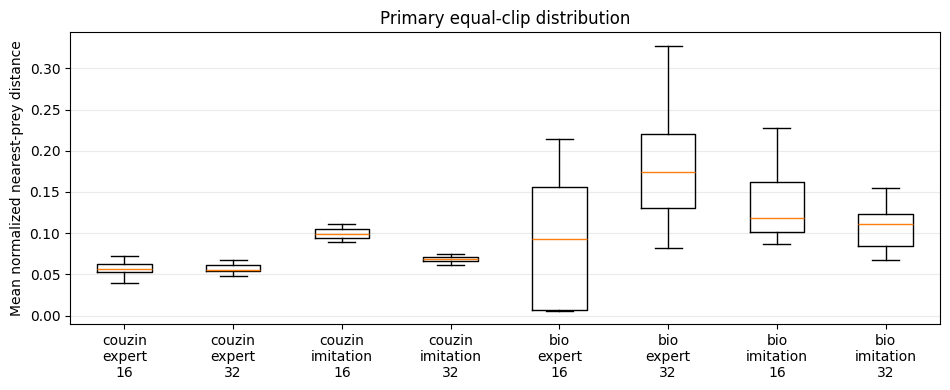

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,0.056987785,0.0073962915,0.056423433,0.05277231,0.062771723,0.054233115,0.059577428
couzin_expert_32,clip (primary),30,0.057037242,0.0056948741,0.0557767,0.053583581,0.060908005,0.055100851,0.059152536
couzin_imitation_16,clip (primary),30,0.099748582,0.0060368357,0.099344395,0.094637394,0.10446795,0.097633868,0.10202945
couzin_imitation_32,clip (primary),30,0.06852755,0.0028088258,0.068720527,0.066732042,0.070480824,0.067532383,0.069548182
bio_expert_16,clip (primary),8,0.093094639,0.080706723,0.045870446,0.0062689427,0.15540743,0.03760612,0.15068237
bio_expert_32,clip (primary),35,0.18842006,0.084892377,0.17478029,0.13105966,0.22073635,0.16116001,0.21917272
bio_imitation_16,clip (primary),30,0.13403423,0.039190341,0.11400273,0.10141975,0.16238973,0.12085897,0.14909889
bio_imitation_32,clip (primary),30,0.11071656,0.030415328,0.11104665,0.084889159,0.12285016,0.10041184,0.1220763


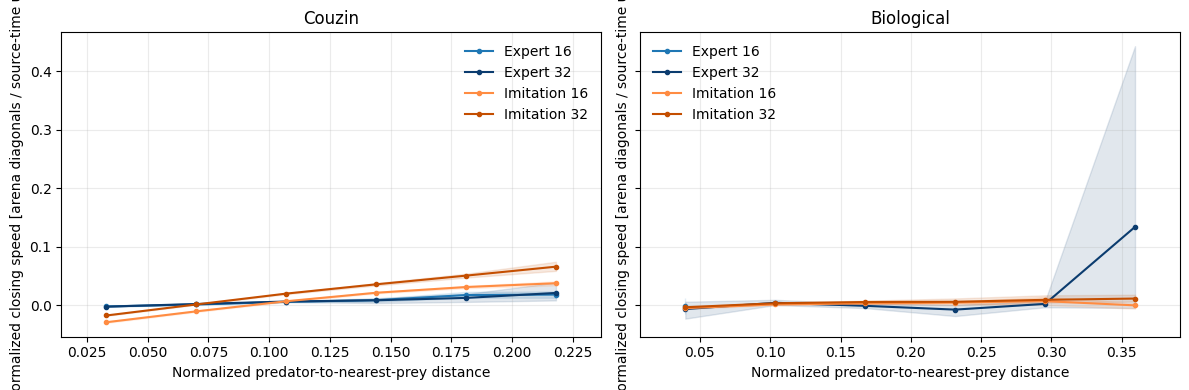

case,bin,distance,sample_weighted_mean,sample_ci_low,sample_ci_high,clip_balanced_mean,clip_ci_low,clip_ci_high,n,clusters,supported
couzin_expert_16,0,0.032916412,-0.0019326439,-0.0024032316,-0.0015000192,-0.002229641,-0.0027469005,-0.0017481694,16093,30,True
couzin_expert_16,1,0.06994462,0.0011761158,0.00079887849,0.0015113683,0.0010705742,0.00071149517,0.0014083494,8807,30,True
couzin_expert_16,2,0.10697283,0.0057060267,0.0050901147,0.0062928852,0.0055885357,0.0048349942,0.0063741696,2962,30,True
couzin_expert_16,3,0.14400104,0.0089254668,0.0076349061,0.010249988,0.0084566809,0.0058127055,0.010846728,952,30,True
couzin_expert_16,4,0.18102925,0.013137736,0.010613455,0.016057933,0.017252695,0.012875618,0.022693528,322,23,True
couzin_expert_16,5,0.21805745,0.01428145,0.010659214,0.018645328,0.01801694,0.012530517,0.023485549,148,19,True
couzin_expert_32,0,0.032916412,-0.0025039571,-0.0028462177,-0.0021916518,-0.0026156912,-0.0029497251,-0.0022806744,15167,30,True
couzin_expert_32,1,0.06994462,0.001980063,0.0016130432,0.0023101117,0.0018915323,0.0014562401,0.0022672983,9469,30,True
couzin_expert_32,2,0.10697283,0.0059206411,0.0054151835,0.0065275133,0.0061351988,0.0055089942,0.0068316371,2871,30,True
couzin_expert_32,3,0.14400104,0.0092466651,0.0083201444,0.010231087,0.0082999691,0.0034955807,0.011827189,1105,30,True


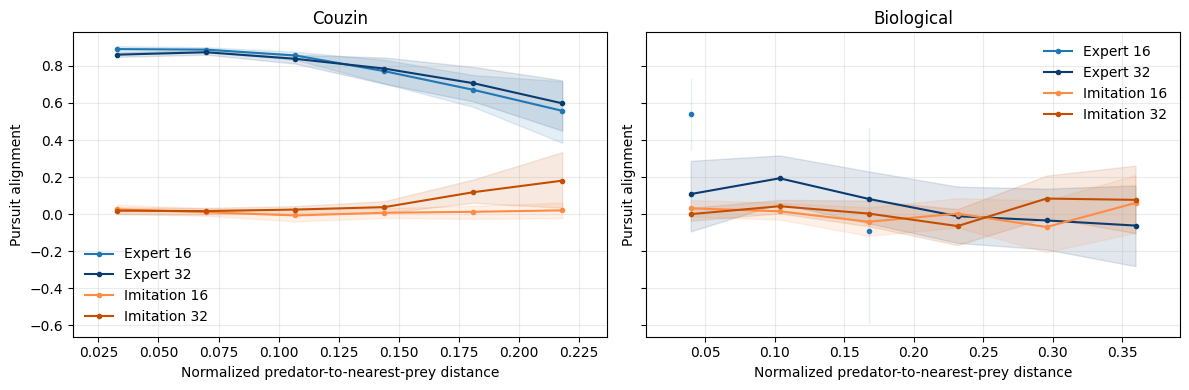

case,bin,distance,sample_weighted_mean,sample_ci_low,sample_ci_high,clip_balanced_mean,clip_ci_low,clip_ci_high,n,clusters,supported
couzin_expert_16,0,0.032916412,0.89912379,0.88530004,0.91272783,0.89039117,0.87512243,0.90624464,16149,30,True
couzin_expert_16,1,0.06994462,0.89066333,0.87939799,0.90128881,0.88768238,0.87519711,0.89996886,8832,30,True
couzin_expert_16,2,0.10697283,0.86869794,0.85343814,0.88327712,0.85622066,0.8331725,0.87633806,2967,30,True
couzin_expert_16,3,0.14400104,0.82348263,0.78691947,0.85672325,0.77143991,0.70462805,0.83265024,952,30,True
couzin_expert_16,4,0.18102925,0.77669352,0.69924772,0.82427025,0.67078996,0.5786311,0.75033504,322,23,True
couzin_expert_16,5,0.21805745,0.74049819,0.60299027,0.82545,0.55768156,0.38442948,0.71699464,148,19,True
couzin_expert_32,0,0.032916412,0.86402345,0.85192144,0.8750487,0.86043447,0.84860295,0.87109953,15213,30,True
couzin_expert_32,1,0.06994462,0.87753767,0.86569273,0.88761848,0.87342066,0.86029983,0.88580567,9494,30,True
couzin_expert_32,2,0.10697283,0.85164917,0.83258152,0.86707944,0.83819681,0.81207323,0.85941142,2877,30,True
couzin_expert_32,3,0.14400104,0.83849496,0.80730247,0.86237997,0.78538859,0.70333469,0.8451373,1113,30,True


{'couzin_expert_16': {'bin_center': [0.03291641175746918,
   0.06994462013244629,
   0.1069728285074234,
   0.1440010368824005,
   0.18102924525737762,
   0.21805745363235474],
  'sample_weighted_mean': [0.8991237878799438,
   0.8906633257865906,
   0.8686979413032532,
   0.8234826326370239,
   0.7766935229301453,
   0.7404981851577759],
  'sample_weighted_ci_low': [0.8853000402450562,
   0.879397988319397,
   0.853438138961792,
   0.7869194746017456,
   0.6992477178573608,
   0.6029902696609497],
  'sample_weighted_ci_high': [0.9127278327941895,
   0.9012888073921204,
   0.8832771182060242,
   0.8567232489585876,
   0.8242702484130859,
   0.8254500031471252],
  'clip_balanced_mean': [0.8903911709785461,
   0.8876823782920837,
   0.8562206625938416,
   0.7714399099349976,
   0.6707899570465088,
   0.5576815605163574],
  'clip_balanced_ci_low': [0.8751224279403687,
   0.8751971125602722,
   0.8331725001335144,
   0.704628050327301,
   0.5786311030387878,
   0.3844294846057892],
  'clip_

In [6]:
# Overall normalized proximity to the nearest-prey proxy: one estimate per clip.
plot_scalar('predator_distance','Mean normalized nearest-prey distance'); show_distribution_values('predator_distance')

# Closing speed is normalized by arena diagonal and declared source-time unit.
plot_curve('closing_speed','Normalized closing speed [arena diagonals / source-time unit]'); show_curve_values('closing_speed')
plot_curve('pursuit_alignment','Pursuit alignment'); show_curve_values('pursuit_alignment')


# Prey Response Metrics

Continuous response fixes the predator-away direction at *t*. Valid responses satisfy `R > 0.10` within the next 20 sampled transitions. Both biological sources use 15 Hz; Couzin time remains simulation time. Right-censored follow-up enters a Kaplan–Meier estimate instead of being removed from the response-fraction denominator.

Escape alignment describes the instantaneous direction of motion. Reaction latency and normalized reaction distance include only responders, while response fraction reports how much of the group responded; the compact sensitivity table checks thresholds 0.075, 0.10, and 0.125.

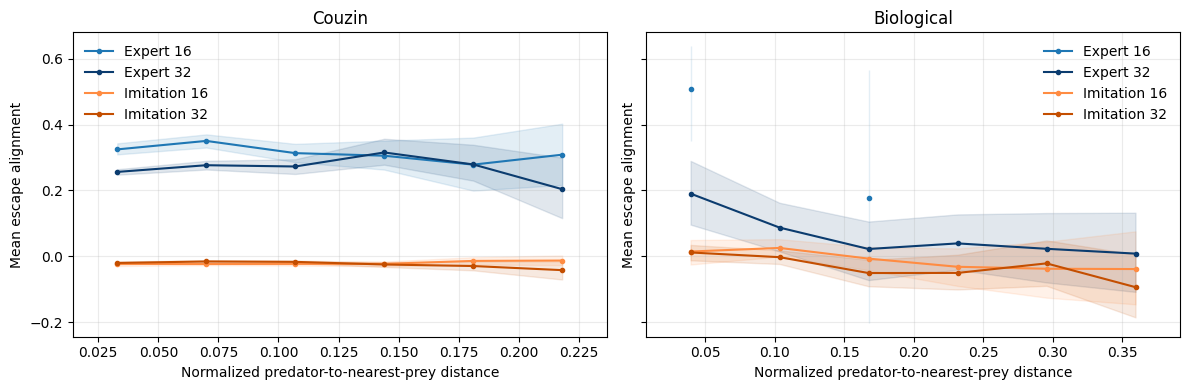

case,bin,distance,sample_weighted_mean,sample_ci_low,sample_ci_high,clip_balanced_mean,clip_ci_low,clip_ci_high,n,clusters,supported
couzin_expert_16,0,0.032916412,0.32660812,0.30938956,0.34811264,0.32497448,0.30977491,0.3433246,16149,30,True
couzin_expert_16,1,0.06994462,0.34403422,0.32465696,0.36532289,0.35076231,0.33065343,0.37060022,8832,30,True
couzin_expert_16,2,0.10697283,0.31356552,0.29009786,0.33767048,0.31362185,0.28629377,0.34179196,2967,30,True
couzin_expert_16,3,0.14400104,0.2977806,0.26728219,0.32868221,0.30575359,0.26344624,0.35159767,952,30,True
couzin_expert_16,4,0.18102925,0.31669825,0.25503352,0.36914939,0.27861318,0.19956566,0.36082366,322,23,True
couzin_expert_16,5,0.21805745,0.34849203,0.23165923,0.4440746,0.3088561,0.21688175,0.40311131,148,19,True
couzin_expert_32,0,0.032916412,0.25600442,0.24772488,0.26445112,0.25649497,0.24805449,0.26463485,15213,30,True
couzin_expert_32,1,0.06994462,0.27793288,0.26451212,0.29156432,0.27685204,0.2637752,0.29014194,9494,30,True
couzin_expert_32,2,0.10697283,0.27571484,0.25421646,0.29612771,0.27297696,0.25018787,0.29501432,2877,30,True
couzin_expert_32,3,0.14400104,0.29353452,0.26045215,0.32971618,0.31565353,0.27841797,0.35732463,1113,30,True


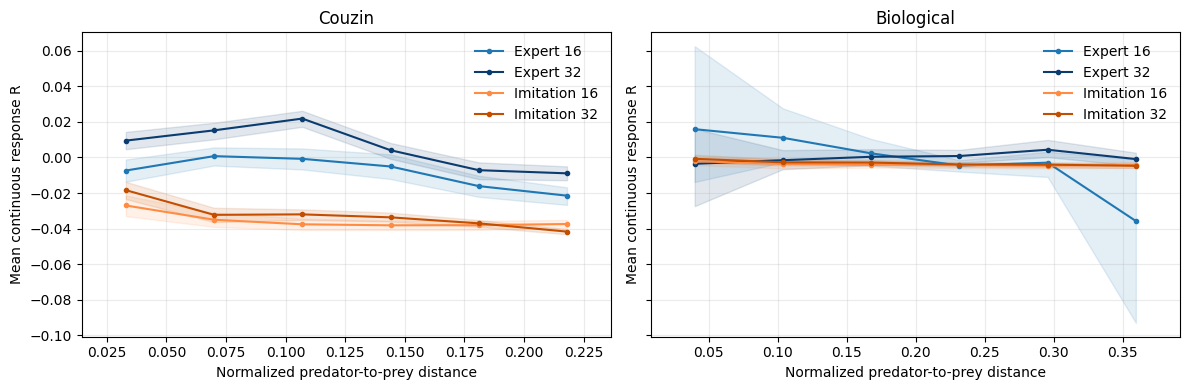

case,bin,distance,sample_weighted_mean,sample_ci_low,sample_ci_high,clip_balanced_mean,clip_ci_low,clip_ci_high,n,clusters,supported
couzin_expert_16,0,0.032916412,-0.014035787,-0.021829903,-0.0051797177,-0.0073556434,-0.013612845,-0.0011729905,23940,30,True
couzin_expert_16,1,0.06994462,-0.0014399255,-0.0073863911,0.0040979674,0.00075084023,-0.0045434409,0.0056390329,20160,30,True
couzin_expert_16,2,0.10697283,-0.0024655601,-0.0099232662,0.0042992947,-0.00077084539,-0.0067548561,0.0050604329,22603,30,True
couzin_expert_16,3,0.14400104,-0.0084659727,-0.016328126,-6.6082088e-05,-0.005058846,-0.012120111,0.0017336732,31482,30,True
couzin_expert_16,4,0.18102925,-0.016981548,-0.02334995,-0.01095153,-0.0160987,-0.022137228,-0.010287458,36000,30,True
couzin_expert_16,5,0.21805745,-0.02165108,-0.026749117,-0.017111775,-0.021473853,-0.026675588,-0.016761819,39847,30,True
couzin_expert_32,0,0.032916412,0.0085584596,0.0034419298,0.013993152,0.0094675878,0.0046385415,0.014361405,20365,30,True
couzin_expert_32,1,0.06994462,0.014557879,0.0094717452,0.019027691,0.015236002,0.010187293,0.019514928,26381,30,True
couzin_expert_32,2,0.10697283,0.020809622,0.016149368,0.025374442,0.021858813,0.017231347,0.026226191,32900,30,True
couzin_expert_32,3,0.14400104,0.0031067352,-0.0020806692,0.0076071555,0.0040747952,-0.00075468392,0.0081517724,47511,30,True


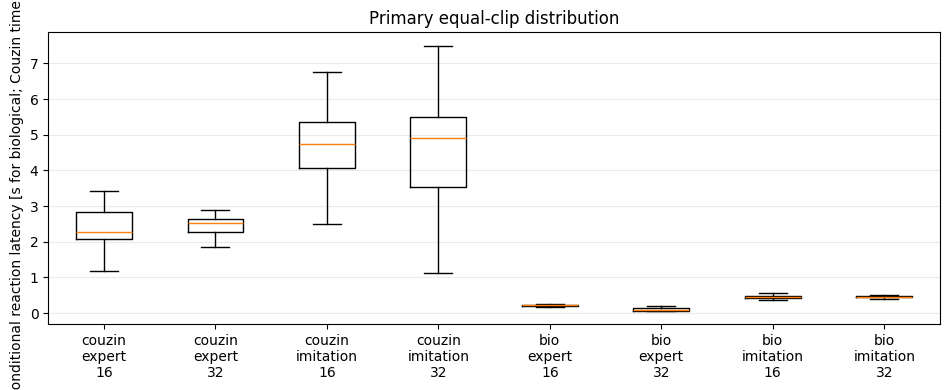

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,2.3961108,0.53501695,2.21875,2.0671506,2.8355904,2.1942761,2.5875609
couzin_expert_32,clip (primary),30,2.5028002,0.38674265,2.515625,2.2847726,2.6439369,2.3720517,2.6407413
couzin_imitation_16,clip (primary),30,4.7726755,1.2358273,4.7000003,4.0718751,5.3703127,4.3277111,5.216218
couzin_imitation_32,clip (primary),27,4.5337582,1.9281317,4.916667,3.5416667,5.5,3.7340732,5.254158
bio_expert_16,clip (primary),7,0.21197517,0.030475143,0.22222224,0.19260752,0.23194447,0.18915771,0.23380056
bio_expert_32,clip (primary),15,0.10643211,0.041657064,0.088888898,0.066666678,0.13333334,0.087362058,0.12964538
bio_imitation_16,clip (primary),30,0.45193335,0.070740446,0.44102567,0.41387534,0.48216343,0.42558041,0.47777319
bio_imitation_32,clip (primary),30,0.45485112,0.041360963,0.45781252,0.43664914,0.47451854,0.44004148,0.46881706


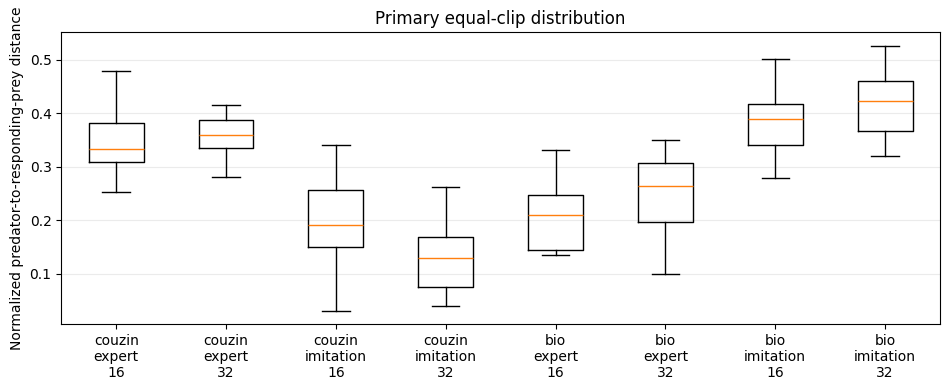

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,0.34339085,0.051524654,0.3323406,0.30860716,0.38215008,0.32561982,0.36225891
couzin_expert_32,clip (primary),30,0.36055762,0.041003145,0.35694811,0.33495754,0.38632494,0.34681377,0.37451917
couzin_imitation_16,clip (primary),30,0.19086923,0.071663499,0.18754815,0.15000993,0.25635123,0.1634544,0.21546929
couzin_imitation_32,clip (primary),27,0.13155852,0.063776925,0.12903756,0.076091744,0.16884498,0.1068243,0.15664423
bio_expert_16,clip (primary),7,0.20811145,0.067216769,0.20881051,0.1437477,0.24712542,0.1611774,0.26205578
bio_expert_32,clip (primary),15,0.25247964,0.066733152,0.26435491,0.19719009,0.30614036,0.21903431,0.28604659
bio_imitation_16,clip (primary),30,0.38085836,0.052025523,0.3844851,0.33965954,0.41743505,0.3635681,0.40029779
bio_imitation_32,clip (primary),30,0.41794318,0.057245061,0.41778153,0.36595023,0.45943147,0.39932278,0.43974626


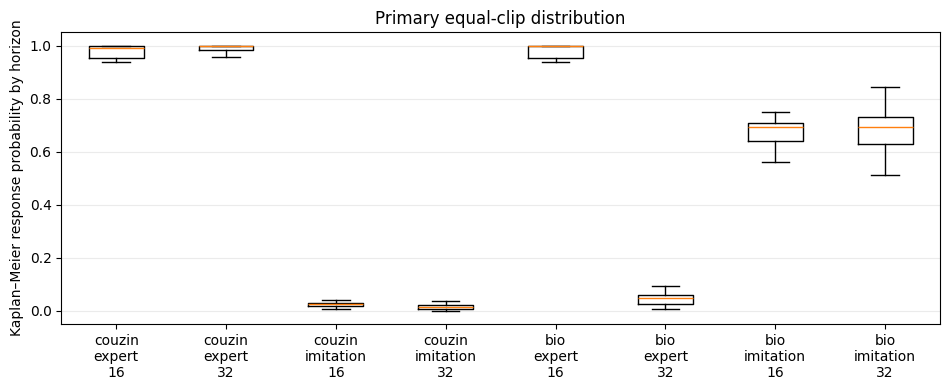

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,0.97381949,0.034404166,0.984375,0.953125,1,0.95995313,0.98524398
couzin_expert_32,clip (primary),30,0.98887157,0.015661115,1,0.98203123,1,0.98361021,0.99425387
couzin_imitation_16,clip (primary),30,0.02546614,0.011437933,0.024038462,0.017361112,0.028470553,0.021477195,0.029748926
couzin_imitation_32,clip (primary),30,0.017533069,0.014367969,0.013392858,0.0078125,0.021949405,0.012781261,0.022950582
bio_expert_16,clip (primary),7,0.95089287,0.084938832,1,0.953125,1,0.88381702,0.99553573
bio_expert_32,clip (primary),15,0.041805558,0.023550628,0.046875,0.025,0.059375003,0.02920139,0.053855035
bio_imitation_16,clip (primary),30,0.67809522,0.077798493,0.6875,0.640625,0.70833337,0.64972049,0.70699281
bio_imitation_32,clip (primary),30,0.68972802,0.086697593,0.69375002,0.63020837,0.73046875,0.66054952,0.72124046


case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,event (diagnostic),69,0.97010869,0.049463488,1,0.9375,1,NaN,NaN
couzin_expert_32,event (diagnostic),65,0.98750001,0.022467926,1,0.96875,1,NaN,NaN
couzin_imitation_16,event (diagnostic),438,0.025399543,0.043856088,0,0,0.0625,NaN,NaN
couzin_imitation_32,event (diagnostic),180,0.019270834,0.032321054,0,0,0.03125,NaN,NaN
bio_expert_16,event (diagnostic),8,0.953125,0.081189878,1,0.9375,1,NaN,NaN
bio_expert_32,event (diagnostic),26,1,0,1,1,1,NaN,NaN
bio_imitation_16,event (diagnostic),119,0.69065124,0.14782402,0.6875,0.625,0.8125,NaN,NaN
bio_imitation_32,event (diagnostic),119,0.68697476,0.12187421,0.6875,0.609375,0.75,NaN,NaN


case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,event (diagnostic),68,0.9696691,0.049691889,1,0.9375,1,NaN,NaN
couzin_expert_32,event (diagnostic),65,0.98750001,0.022467926,1,0.96875,1,NaN,NaN
couzin_imitation_16,event (diagnostic),438,0.025399543,0.043856088,0,0,0.0625,NaN,NaN
couzin_imitation_32,event (diagnostic),180,0.019270834,0.032321054,0,0,0.03125,NaN,NaN
bio_expert_16,event (diagnostic),8,0.953125,0.081189878,1,0.9375,1,NaN,NaN
bio_expert_32,event (diagnostic),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bio_imitation_16,event (diagnostic),117,0.68536323,0.14339343,0.6875,0.625,0.8125,NaN,NaN
bio_imitation_32,event (diagnostic),118,0.68432206,0.11891922,0.6875,0.6015625,0.75,NaN,NaN


case,robust_approach_events,fully_classified_events,responders,confirmed_nonresponders,right_censored,mean_KM_response_fraction
couzin_expert_16,69,68,1070,33,1,0.97381949
couzin_expert_32,65,65,2054,26,0,0.98887151
couzin_imitation_16,438,438,178,6830,0,0.02546614
couzin_imitation_32,183,180,111,5649,96,0.017533068
bio_expert_16,8,8,122,6,0,0.95089287
bio_expert_32,45,0,49,0,1391,0.041805558
bio_imitation_16,119,117,1303,589,12,0.67809522
bio_imitation_32,119,118,2603,1192,13,0.68972802


case,threshold,events,contributing_clips,mean_KM_response_fraction,fraction_complete_events_two_plus
couzin_expert_16,0.075,69,30,0.97373188,1
couzin_expert_16,0.1,69,30,0.96920294,1
couzin_expert_16,0.125,69,30,0.96557975,1
couzin_expert_32,0.075,65,30,0.98990387,1
couzin_expert_32,0.1,65,30,0.98750001,1
couzin_expert_32,0.125,65,30,0.98317307,1
couzin_imitation_16,0.075,438,30,0.11900684,0.56392694
couzin_imitation_16,0.1,438,30,0.025399541,0.077625565
couzin_imitation_16,0.125,438,30,0.018550228,0.050228309
couzin_imitation_32,0.075,183,30,0.035519123,0.31111112


In [7]:
# Directional escape behavior and continuous change in away-alignment.
plot_curve('escape_alignment','Mean escape alignment'); show_curve_values('escape_alignment')
plot_curve('continuous_predator_response_curve','Mean continuous response R','Normalized predator-to-prey distance'); show_curve_values('continuous_predator_response_curve')

# Primary inferential summaries use one value per independent clip.
plot_scalar('reaction_latency_time','Conditional reaction latency [s for biological; Couzin time units]'); show_distribution_values('reaction_latency_time')
plot_scalar('reaction_distance_norm','Normalized predator-to-responding-prey distance'); show_distribution_values('reaction_distance_norm')
plot_scalar('response_fraction','Kaplan–Meier response probability by horizon'); show_distribution_values('response_fraction')

# Per-event values are retained only as transparent diagnostics.
show_distribution_values('response_fraction_classified',event=True)
show_distribution_values('response_fraction_complete_case',event=True)
censoring_rows=[]
for name,r in case_results.items():
 ev=r['events']; responders=int(ev['observed_responder_count'].sum()); nonresponders=int(ev['confirmed_non_responder_count'].sum()); censored=int(ev['censored_count'].sum())
 complete=int(torch.isfinite(ev['response_fraction_complete_case']).sum())
 censoring_rows.append({'case':name,'robust_approach_events':len(ev['censored_count']),'fully_classified_events':complete,
  'responders':responders,'confirmed_nonresponders':nonresponders,'right_censored':censored,
  'mean_KM_response_fraction':float(r['per_clip']['response_fraction'].nanmean())})
display_table(censoring_rows,'Response classification, right censoring, and KM primary estimate')

sensitivity_rows=[]
for case_name,thresholds in results['response_threshold_sensitivity'].items():
 for threshold,summary in thresholds.items():
  sensitivity_rows.append({'case':case_name,'threshold':threshold,'events':summary['events'],
   'contributing_clips':summary['contributing_clips'],'mean_KM_response_fraction':float(summary['mean_response_fraction'].detach().cpu()),
   'fraction_complete_events_two_plus':float(summary['fraction_events_two_plus'].detach().cpu())})
display_table(sensitivity_rows,'Response-threshold sensitivity')


## Risk-bin diagnostics and common-support comparison

The diagnostics below separate insufficient sample support, insufficient independent-clip support, non-finite metric values, and observations clipped by the declared q01–q99 range. The original curves above remain unchanged. A common-support range is accepted only if all six risk-conditioned metrics satisfy both support thresholds in every one of the four cases of a source after rebinning into ten equal-width bins. Candidate boundaries are restricted to the original bin edges, making excluded original bins explicit.

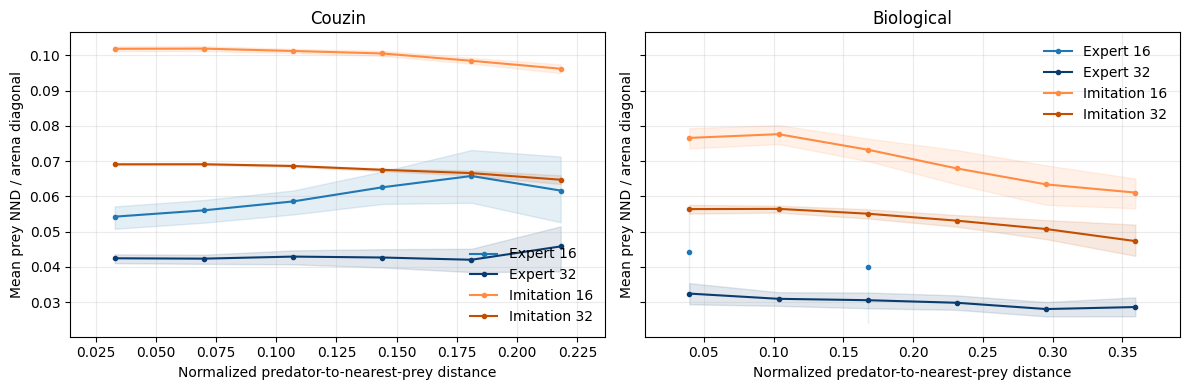

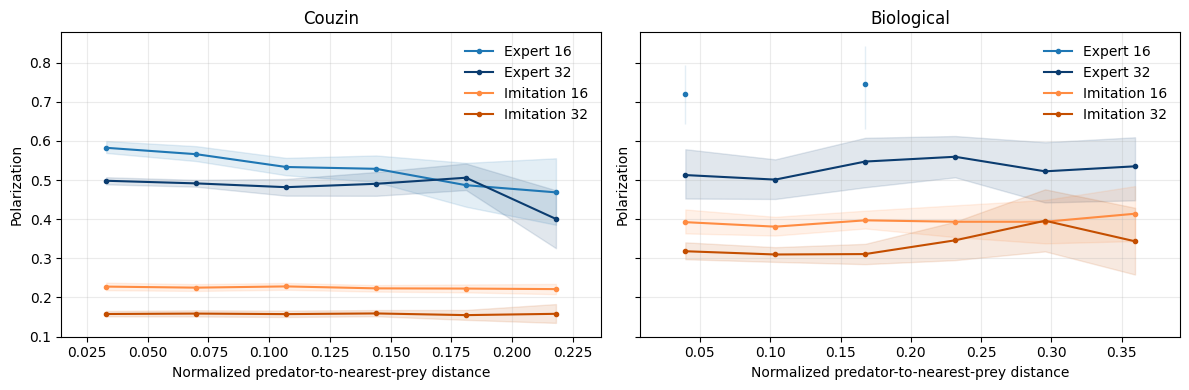

case,metric,bin,left,right,samples,clips,candidate_samples_before_metric_NaNs,candidate_clips_before_metric_NaNs,missing_metric_values,fails_min_samples_30,fails_min_clips_5,NaNs_cause_support_loss,range_clipping_note,sample_weighted_NaN,clip_balanced_NaN,both_estimators_affected,reason
bio_expert_16,closing_speed,1,0.071625501,0.13557282,196,3,196,3,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,closing_speed,2,0.13557282,0.19952014,515,4,515,4,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,closing_speed,3,0.19952014,0.26346746,224,4,224,4,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,closing_speed,4,0.26346746,0.32741478,85,2,85,2,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,closing_speed,5,0.32741478,0.3913621,0,0,0,0,0,True,True,False,raw exclusions reported in next table,True,True,True,"sample support, clip support"
bio_expert_16,pursuit_alignment,1,0.071625501,0.13557282,200,3,200,3,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,pursuit_alignment,3,0.19952014,0.26346746,224,4,224,4,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,pursuit_alignment,4,0.26346746,0.32741478,85,2,85,2,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support
bio_expert_16,pursuit_alignment,5,0.32741478,0.3913621,0,0,0,0,0,True,True,False,raw exclusions reported in next table,True,True,True,"sample support, clip support"
bio_expert_16,escape_alignment,1,0.071625501,0.13557282,200,3,200,3,0,False,True,False,raw exclusions reported in next table,True,True,True,clip support


case,metric,finite_distances,min,max,"outside_[0,1]",below_declared_range,above_declared_range,nonfinite_distance
couzin_expert_16,closing_speed,29910,0,0.30333093,0,581,45,0
couzin_expert_16,pursuit_alignment,30000,0,0.30333093,0,585,45,0
couzin_expert_16,escape_alignment,30000,0,0.30333093,0,585,45,0
couzin_expert_16,risk_conditioned_nnd,30000,0,0.30333093,0,585,45,0
couzin_expert_16,risk_conditioned_polarization,30000,0,0.30333093,0,585,45,0
couzin_expert_16,continuous_predator_response_curve,479520,0,0.93442023,0,957,304531,0
couzin_expert_32,closing_speed,29910,0,0.3395696,0,895,34,0
couzin_expert_32,pursuit_alignment,30000,0,0.3395696,0,896,34,0
couzin_expert_32,escape_alignment,30000,0,0.3395696,0,896,34,0
couzin_expert_32,risk_conditioned_nnd,30000,0,0.3395696,0,896,34,0


source,original_low,original_high,common_low,common_high,excluded_original_bins,candidates_tested,missing_cases,status
couzin,0.014402304,0.23657157,0.014402304,0.23657157,[],1,,supported
biological,0.0076781777,0.3913621,NaN,NaN,all / no feasible 6-bin range,21,,no range satisfies every case and metric


source,case,metric,supported_bins,total_bins,minimum_samples,minimum_clips
couzin,couzin_expert_16,closing_speed,6,6,148,19
couzin,couzin_expert_16,pursuit_alignment,6,6,148,19
couzin,couzin_expert_16,escape_alignment,6,6,148,19
couzin,couzin_expert_16,risk_conditioned_nnd,6,6,148,19
couzin,couzin_expert_16,risk_conditioned_polarization,6,6,148,19
couzin,couzin_expert_16,continuous_predator_response_curve,6,6,20160,30
couzin,couzin_expert_32,closing_speed,6,6,78,14
couzin,couzin_expert_32,pursuit_alignment,6,6,81,14
couzin,couzin_expert_32,escape_alignment,6,6,81,14
couzin,couzin_expert_32,risk_conditioned_nnd,6,6,81,14


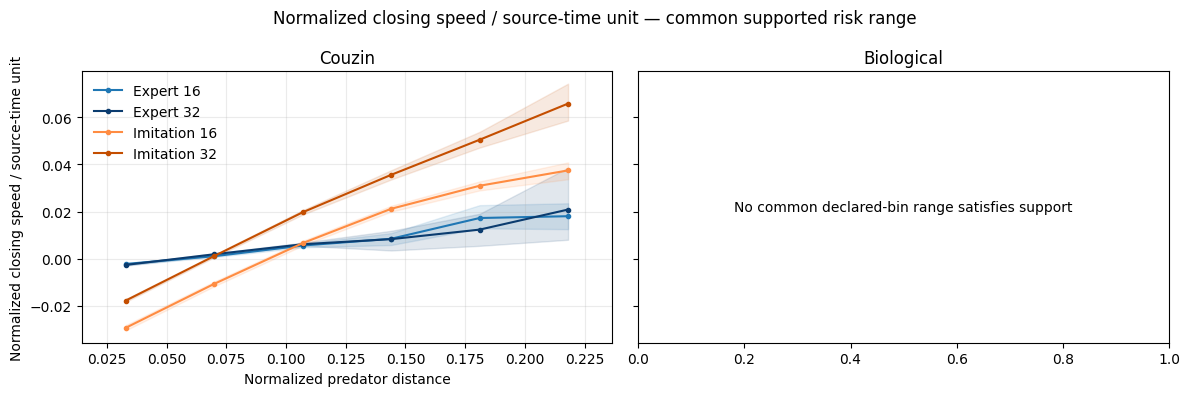

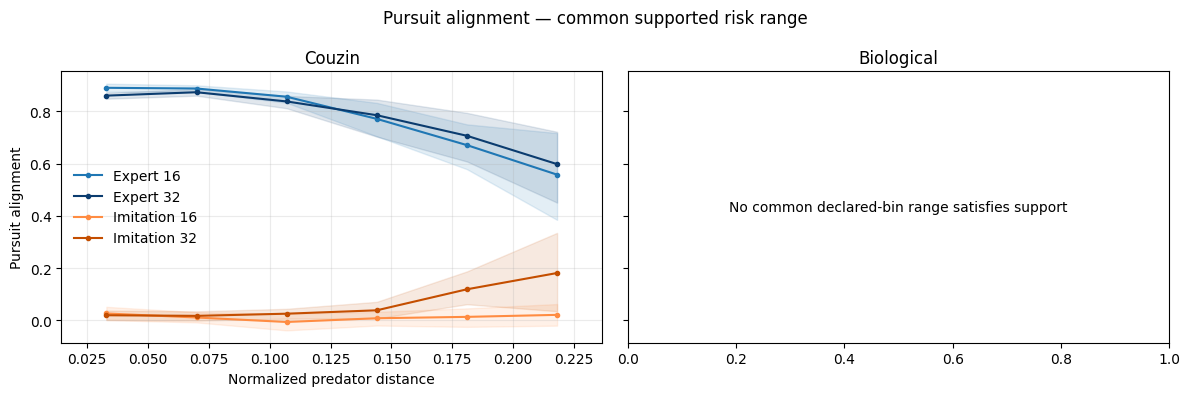

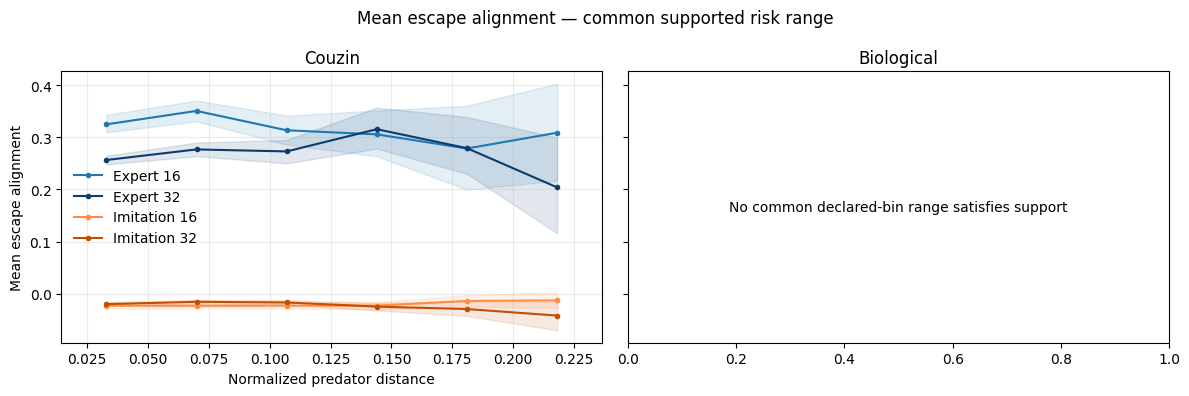

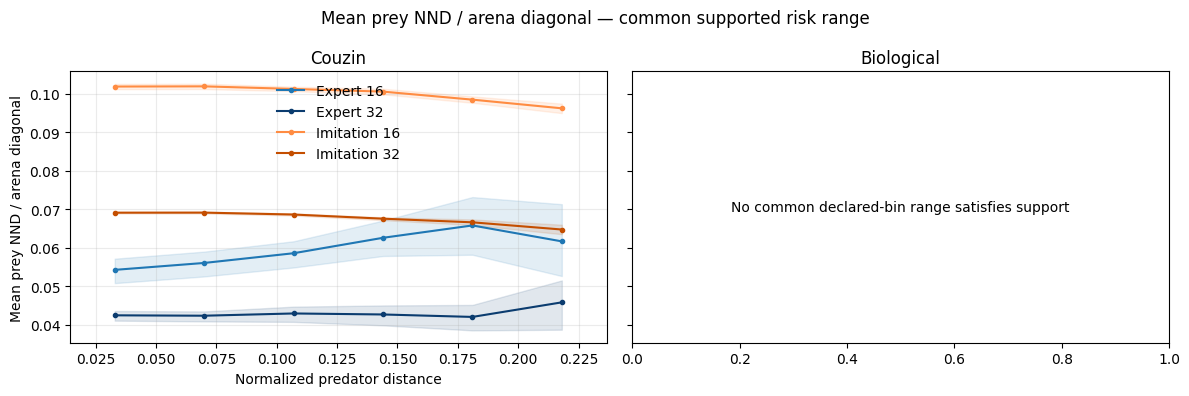

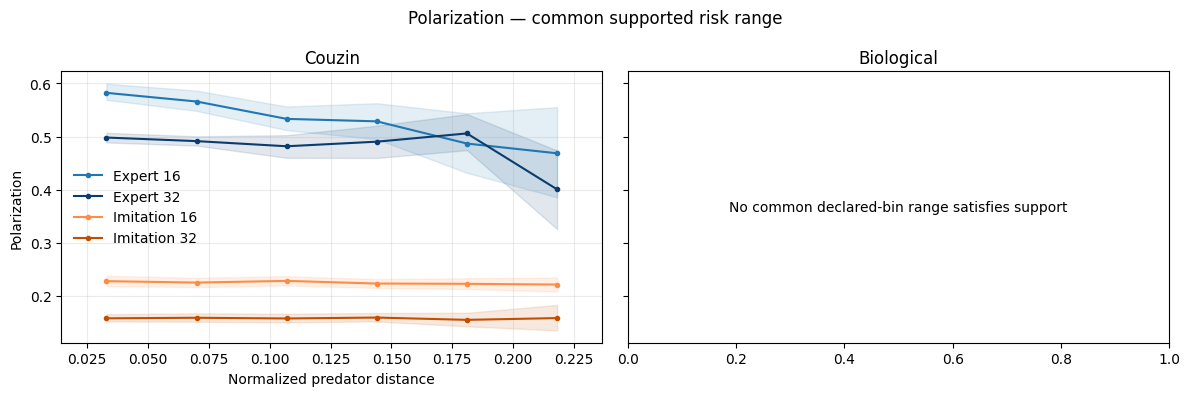

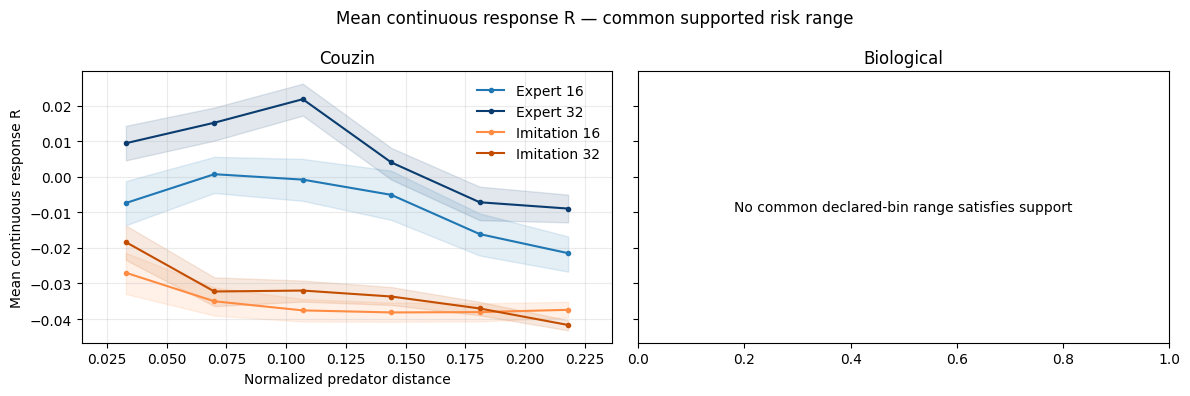

In [8]:
RISK_CURVE_METRICS=('closing_speed','pursuit_alignment','escape_alignment','risk_conditioned_nnd','risk_conditioned_polarization','continuous_predator_response_curve')
RISK_CURVE_LABELS={'closing_speed':'Normalized closing speed / source-time unit','pursuit_alignment':'Pursuit alignment','escape_alignment':'Mean escape alignment','risk_conditioned_nnd':'Mean prey NND / arena diagonal','risk_conditioned_polarization':'Polarization','continuous_predator_response_curve':'Mean continuous response R'}
SOURCE_CASES={'couzin':('couzin_expert_16','couzin_expert_32','couzin_imitation_16','couzin_imitation_32'),'biological':('bio_expert_16','bio_expert_32','bio_imitation_16','bio_imitation_32')}

# Add the two original q01-q99 curves that were calculated but not previously plotted.
plot_curve('risk_conditioned_nnd','Mean prey NND / arena diagonal')
plot_curve('risk_conditioned_polarization','Polarization')

# Report every unsupported or non-finite original bin, including the exact reason.
risk_bin_diagnostic_rows=[]; risk_normalization_rows=[]
for name,r in case_results.items():
 for metric in RISK_CURVE_METRICS:
  c=r['curves'][metric]; sample_finite=torch.isfinite(c['sample_weighted_mean']); clip_finite=torch.isfinite(c['clip_balanced_mean'])
  candidate_supported=(c['candidate_count']>=MIN_SAMPLES_PER_BIN)&(c['candidate_cluster_count']>=MIN_CLIPS_PER_BIN)
  for b in range(len(c['supported'])):
   if bool(c['supported'][b]) and bool(sample_finite[b]) and bool(clip_finite[b]): continue
   sample_fail=int(c['count'][b])<MIN_SAMPLES_PER_BIN; clip_fail=int(c['cluster_count'][b])<MIN_CLIPS_PER_BIN
   nan_caused=bool(candidate_supported[b] and not c['supported'][b])
   reasons=[]
   if sample_fail: reasons.append('sample support')
   if clip_fail: reasons.append('clip support')
   if nan_caused: reasons.append('non-finite metric values')
   risk_bin_diagnostic_rows.append({'case':name,'metric':metric,'bin':b,'left':float(c['bin_left'][b]),'right':float(c['bin_right'][b]),'samples':int(c['count'][b]),'clips':int(c['cluster_count'][b]),'candidate_samples_before_metric_NaNs':int(c['candidate_count'][b]),'candidate_clips_before_metric_NaNs':int(c['candidate_cluster_count'][b]),'missing_metric_values':int(c['missing_value_count'][b]),'fails_min_samples_30':sample_fail,'fails_min_clips_5':clip_fail,'NaNs_cause_support_loss':nan_caused,'range_clipping_note':'raw exclusions reported in next table','sample_weighted_NaN':not bool(sample_finite[b]),'clip_balanced_NaN':not bool(clip_finite[b]),'both_estimators_affected':not bool(sample_finite[b]) and not bool(clip_finite[b]),'reason':', '.join(reasons) if reasons else 'non-finite estimator'})
  raw=r['risk_curve_clusters'][metric]; x=torch.cat(raw['x']) if raw['x'] else torch.empty(0,device=DEVICE)
  finite=x[torch.isfinite(x)]; low,high=RISK_RANGES[_style(name)[0]]
  risk_normalization_rows.append({'case':name,'metric':metric,'finite_distances':len(finite),'min':float(finite.min()) if len(finite) else np.nan,'max':float(finite.max()) if len(finite) else np.nan,'outside_[0,1]':int(((finite<0)|(finite>1)).sum()),'below_declared_range':int((finite<low).sum()),'above_declared_range':int((finite>high).sum()),'nonfinite_distance':int((~torch.isfinite(x)).sum())})
display_table(risk_bin_diagnostic_rows,'Unsupported/NaN original risk bins and exact causes')
display_table(risk_normalization_rows,'Risk-distance normalization and q01-q99 clipping diagnostics')

def _rebin_case_curve(case_name,metric,edges,n_bootstrap=0):
 raw=case_results[case_name]['risk_curve_clusters'][metric]
 return pa.cluster_bootstrap_risk_conditioned_mean(raw['x'],raw['values'],edges,min_count=MIN_SAMPLES_PER_BIN,min_cluster_count=MIN_CLIPS_PER_BIN,n_bootstrap=n_bootstrap,ci_level=CI_LEVEL,seed=ROLLOUT_SEEDS[0])

# Search widest first. Requiring support after the declared-bin rebin prevents a coarse supported bin from hiding unsupported subdivisions.
common_risk_ranges={}; common_risk_results={}; common_range_rows=[]; common_support_rows=[]
for source,names in SOURCE_CASES.items():
 original=RISK_BIN_EDGES[source]; missing=[name for name in names if name not in case_results]
 chosen=None; tested=0
 if not missing:
  candidates=sorted(((j-i,i,j) for i in range(N_DISTANCE_BINS) for j in range(i+1,N_DISTANCE_BINS+1)),key=lambda z:(-z[0],z[1]))
  for _,start,stop in candidates:
   tested+=1; edges=torch.linspace(original[start],original[stop],N_DISTANCE_BINS+1,device=DEVICE,dtype=DTYPE); ok=True
   for name in names:
    for metric in RISK_CURVE_METRICS:
     if not bool(_rebin_case_curve(name,metric,edges,0)['supported'].all()): ok=False; break
    if not ok: break
   if ok: chosen=(start,stop,edges); break
 if chosen is None:
  common_risk_ranges[source]=None; common_risk_results[source]={}
  common_range_rows.append({'source':source,'original_low':float(original[0]),'original_high':float(original[-1]),'common_low':np.nan,'common_high':np.nan,'excluded_original_bins':f'all / no feasible {N_DISTANCE_BINS}-bin range','candidates_tested':tested,'missing_cases':', '.join(missing),'status':'no range satisfies every case and metric'})
  continue
 start,stop,edges=chosen; common_risk_ranges[source]=edges; common_risk_results[source]={}
 excluded=list(range(0,start))+list(range(stop,N_DISTANCE_BINS))
 common_range_rows.append({'source':source,'original_low':float(original[0]),'original_high':float(original[-1]),'common_low':float(edges[0]),'common_high':float(edges[-1]),'excluded_original_bins':str(excluded),'candidates_tested':tested,'missing_cases':'','status':'supported'})
 for name in names:
  common_risk_results[source][name]={}
  for metric in RISK_CURVE_METRICS:
   c=_rebin_case_curve(name,metric,edges,N_BOOTSTRAP); common_risk_results[source][name][metric]=c
   common_support_rows.append({'source':source,'case':name,'metric':metric,'supported_bins':int(c['supported'].sum()),'total_bins':len(c['supported']),'minimum_samples':int(c['count'].min()),'minimum_clips':int(c['cluster_count'].min())})
display_table(common_range_rows,'Original versus common-support risk ranges')
display_table(common_support_rows,'Per-case support after common-range declared-bin rebinning')

def plot_common_risk_curve(metric):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  if not common_risk_results[source]:
   ax.text(.5,.5,'No common declared-bin range satisfies support',ha='center',va='center',transform=ax.transAxes,wrap=True); ax.set_title(source.title()); continue
  for name in SOURCE_CASES[source]:
   c=common_risk_results[source][name][metric]; _,style=_style(name); x=c['bin_center'].cpu(); mean=c['clip_balanced_mean'].cpu()
   ax.plot(x,mean,marker='o',ms=3,color=COLORS[style],label=style.replace('_',' ').title()); ax.fill_between(x,c['clip_balanced_ci_low'].cpu(),c['clip_balanced_ci_high'].cpu(),color=COLORS[style],alpha=.12)
  ax.set(title=source.title(),xlabel='Normalized predator distance',ylabel=RISK_CURVE_LABELS[metric],xlim=(float(common_risk_ranges[source][0]),float(common_risk_ranges[source][-1]))); ax.grid(alpha=.25); ax.legend(frameon=False)
 fig.suptitle(f'{RISK_CURVE_LABELS[metric]} — common supported risk range'); fig.tight_layout(); plt.show(); plt.close(fig)
for metric in RISK_CURVE_METRICS: plot_common_risk_curve(metric)
results['risk_bin_diagnostics']=risk_bin_diagnostic_rows; results['risk_normalization_diagnostics']=risk_normalization_rows; results['common_supported_risk']={'ranges':common_risk_ranges,'curves':common_risk_results,'support':common_support_rows}


# Collective Response Metrics

Event-relative NND reports the relative change from approach onset, while polarization reports the absolute change. DoS and DoA summarize all valid frames; cascade and propagation reuse the same individual first-response times, with propagation defined only when at least two prey respond.

The final table separates population-size consistency/sensitivity across the two trained sizes from imitation fidelity at each size; it is not an out-of-distribution generalization test.

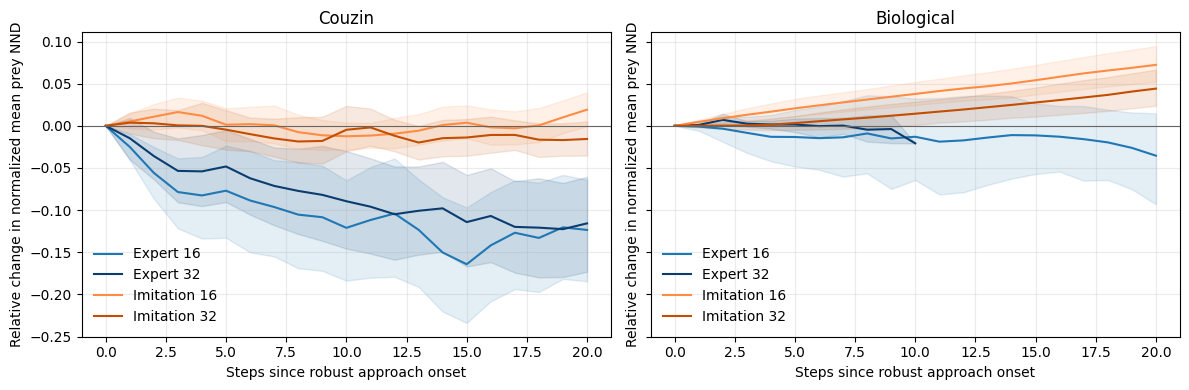

case,step,clip_balanced_mean,ci_low,ci_high,clips
couzin_expert_16,0,0,0,0,30
couzin_expert_16,1,-0.025053266,-0.040585931,-0.0097980751,30
couzin_expert_16,2,-0.055840734,-0.086428508,-0.025123803,30
couzin_expert_16,3,-0.078600325,-0.12172816,-0.038613636,30
couzin_expert_16,4,-0.0826042,-0.13382021,-0.036949899,30
couzin_expert_16,5,-0.076982394,-0.13279112,-0.0235362,30
couzin_expert_16,6,-0.088624254,-0.15014702,-0.029922595,30
couzin_expert_16,7,-0.096329242,-0.15496925,-0.040866707,30
couzin_expert_16,8,-0.10539101,-0.16896865,-0.043133665,30
couzin_expert_16,9,-0.10844263,-0.17207044,-0.047384683,30


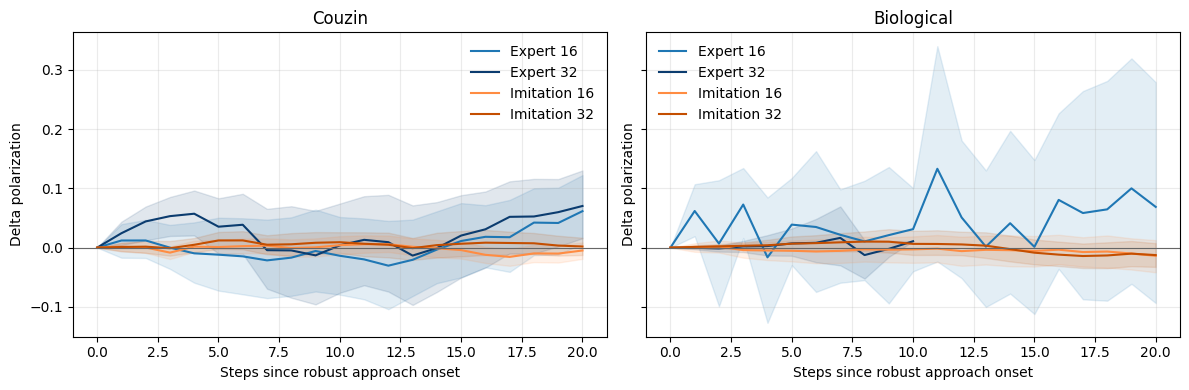

case,step,clip_balanced_mean,ci_low,ci_high,clips
couzin_expert_16,0,0,0,0,30
couzin_expert_16,1,0.012006822,-0.017076291,0.039658427,30
couzin_expert_16,2,0.012060808,-0.017524216,0.046811655,30
couzin_expert_16,3,-5.2701929e-05,-0.035917271,0.038311988,30
couzin_expert_16,4,-0.0096448567,-0.059233427,0.042590633,30
couzin_expert_16,5,-0.011919145,-0.07257726,0.050449137,30
couzin_expert_16,6,-0.014739567,-0.078830995,0.049509164,30
couzin_expert_16,7,-0.021549735,-0.08530394,0.047203291,30
couzin_expert_16,8,-0.016935199,-0.081455611,0.051123466,30
couzin_expert_16,9,-0.0056926832,-0.074063987,0.064199984,30


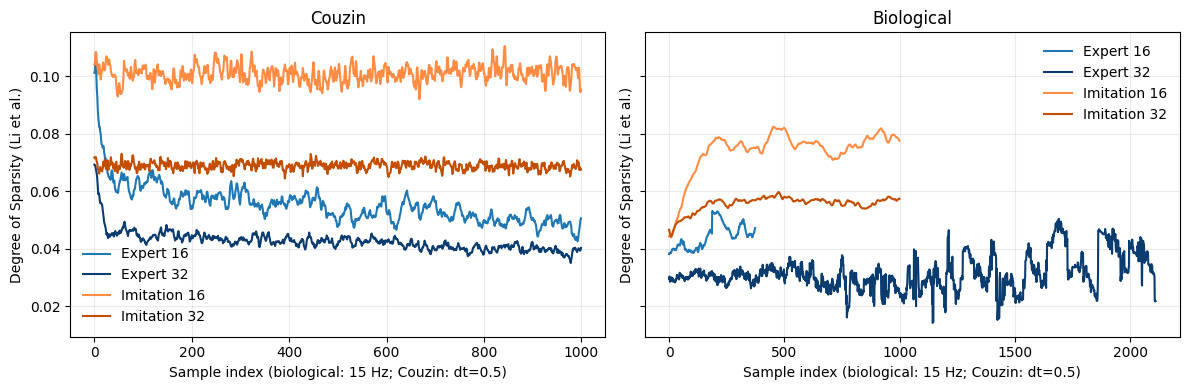

case,steps,clips,aggregate_mean,aggregate_std
couzin_expert_16,1000,30,0.055419307,0.0086260773
couzin_expert_32,1000,30,0.042554013,0.00357424
couzin_imitation_16,1000,30,0.10086323,0.0013402727
couzin_imitation_32,1000,30,0.068867974,0.00051870069
bio_expert_16,374,8,0.039555445,0.015533298
bio_expert_32,2111,35,0.030262154,0.0055890167
bio_imitation_16,1000,30,0.073987462,0.0061595417
bio_imitation_32,1000,30,0.055601958,0.0027968518


case,step,mean,clips
couzin_expert_16,0,0.10114656,30
couzin_expert_16,1,0.10162736,30
couzin_expert_16,2,0.1042422,30
couzin_expert_16,3,0.10418398,30
couzin_expert_16,4,0.10038885,30
couzin_expert_16,5,0.095517956,30
couzin_expert_16,6,0.093018219,30
couzin_expert_16,7,0.088523649,30
couzin_expert_16,8,0.085749671,30
couzin_expert_16,9,0.083869174,30


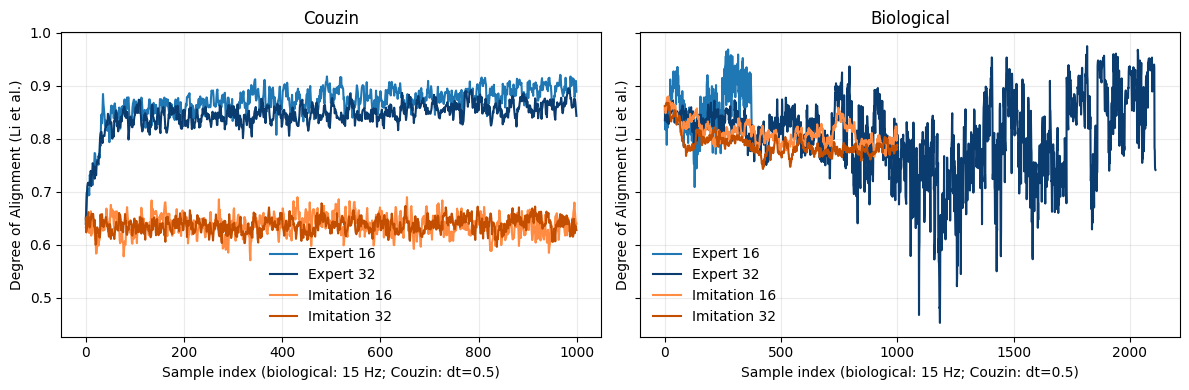

case,steps,clips,aggregate_mean,aggregate_std
couzin_expert_16,1000,30,0.86950368,0.02725403
couzin_expert_32,1000,30,0.84522927,0.019241054
couzin_imitation_16,1000,30,0.63712639,0.010616299
couzin_imitation_32,1000,30,0.63708651,0.0078963144
bio_expert_16,374,8,0.87256557,0.03566137
bio_expert_32,2111,35,0.8327865,0.055062301
bio_imitation_16,1000,30,0.8113758,0.022030031
bio_imitation_32,1000,30,0.78881145,0.028765786


case,step,mean,clips
couzin_expert_16,0,0.64784908,30
couzin_expert_16,1,0.67306161,30
couzin_expert_16,2,0.6986258,30
couzin_expert_16,3,0.69115537,30
couzin_expert_16,4,0.70409191,30
couzin_expert_16,5,0.70380205,30
couzin_expert_16,6,0.70527434,30
couzin_expert_16,7,0.69354784,30
couzin_expert_16,8,0.73154032,30
couzin_expert_16,9,0.72633326,30


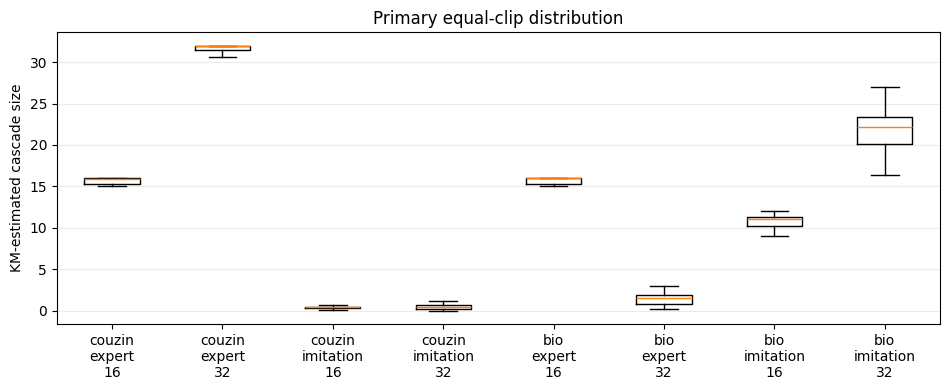

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,15.581112,0.55046666,15.75,15.25,16,15.35925,15.763904
couzin_expert_32,clip (primary),30,31.64389,0.50115567,32,31.424999,32,31.475527,31.816124
couzin_imitation_16,clip (primary),30,0.40745825,0.18300693,0.38461539,0.27777779,0.45552886,0.34363511,0.47598282
couzin_imitation_32,clip (primary),30,0.56105822,0.459775,0.42857146,0.25,0.70238096,0.40900037,0.73441863
bio_expert_16,clip (primary),7,15.214286,1.3590213,16,15.25,16,14.141072,15.928572
bio_expert_32,clip (primary),15,1.3377779,0.75362009,1.5,0.80000001,1.9000001,0.93444449,1.7233611
bio_imitation_16,clip (primary),30,10.849524,1.2447759,11,10.25,11.333334,10.395528,11.311885
bio_imitation_32,clip (primary),30,22.071297,2.774323,22.200001,20.166668,23.375,21.137585,23.079695


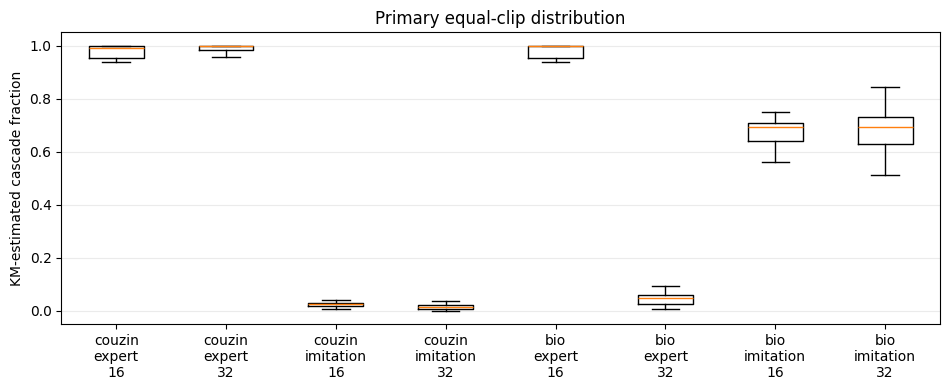

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,0.97381949,0.034404166,0.984375,0.953125,1,0.95995313,0.98524398
couzin_expert_32,clip (primary),30,0.98887157,0.015661115,1,0.98203123,1,0.98361021,0.99425387
couzin_imitation_16,clip (primary),30,0.02546614,0.011437933,0.024038462,0.017361112,0.028470553,0.021477195,0.029748926
couzin_imitation_32,clip (primary),30,0.017533069,0.014367969,0.013392858,0.0078125,0.021949405,0.012781261,0.022950582
bio_expert_16,clip (primary),7,0.95089287,0.084938832,1,0.953125,1,0.88381702,0.99553573
bio_expert_32,clip (primary),15,0.041805558,0.023550628,0.046875,0.025,0.059375003,0.02920139,0.053855035
bio_imitation_16,clip (primary),30,0.67809522,0.077798493,0.6875,0.640625,0.70833337,0.64972049,0.70699281
bio_imitation_32,clip (primary),30,0.68972802,0.086697593,0.69375002,0.63020837,0.73046875,0.66054952,0.72124046


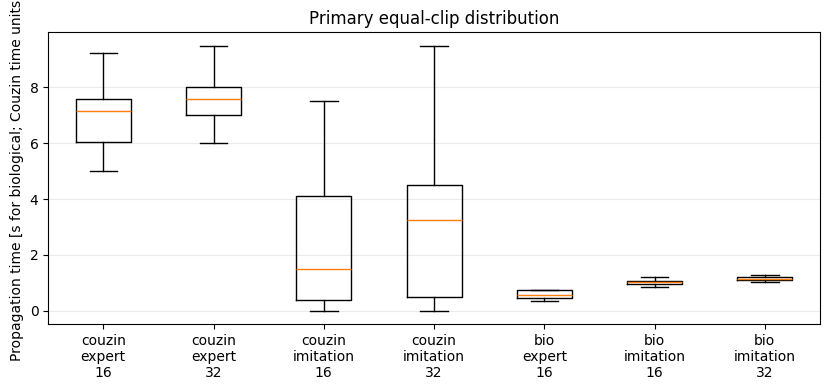

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,6.8280559,1.1692421,7,6.041667,7.59375,6.379097,7.1977782
couzin_expert_32,clip (primary),30,7.3677778,1.257849,7.5,7,8,6.9198747,7.7733889
couzin_imitation_16,clip (primary),23,2.4166667,2.2398455,1.5,0.375,4.125,1.5179348,3.3627717
couzin_imitation_32,clip (primary),17,3.2794118,2.9999919,3.25,0.5,4.5,1.9018384,4.691299
bio_expert_16,clip (primary),7,0.64285713,0.26709151,0.56666672,0.4666667,0.73333335,0.46666667,0.85714287
bio_expert_32,clip (primary),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bio_imitation_16,clip (primary),30,1.0069842,0.099248342,1.0333334,0.9666667,1.075,0.96906352,1.0389485
bio_imitation_32,clip (primary),30,1.13421,0.082836732,1.1444445,1.0808334,1.2,1.1063529,1.1623485


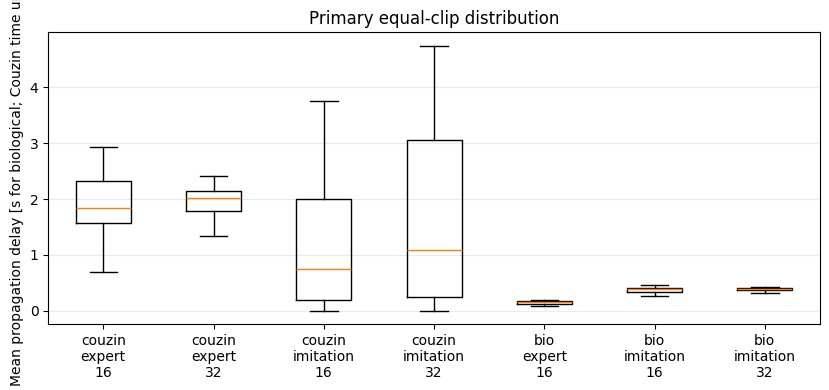

case,unit,n,mean,std,median,q25,q75,clip_bootstrap_ci_low,clip_bootstrap_ci_high
couzin_expert_16,clip (primary),30,1.8984152,0.52974188,1.71875,1.5679687,2.3203125,1.6916572,2.0820332
couzin_expert_32,clip (primary),30,2.0046718,0.38790229,2.015625,1.7855763,2.143631,1.8726463,2.1421776
couzin_imitation_16,clip (primary),23,1.1857488,1.1139801,0.75,0.1875,2,0.74184781,1.6581737
couzin_imitation_32,clip (primary),17,1.6666669,1.5424117,1.0833334,0.25,3.0625,0.95928323,2.4497857
bio_expert_16,clip (primary),7,0.14565477,0.030276937,0.15555556,0.12715277,0.16527778,0.12283731,0.16746081
bio_expert_32,clip (primary),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bio_imitation_16,clip (primary),30,0.37302187,0.062302131,0.37445891,0.34251645,0.39864379,0.3496668,0.39428777
bio_imitation_32,clip (primary),30,0.38920534,0.040279523,0.38873488,0.37074095,0.40724313,0.37439549,0.40308398


case,valid_complete_propagation_events,robust_approach_events,fraction_valid
couzin_expert_16,68,69,0.98550725
couzin_expert_32,65,65,1
couzin_imitation_16,34,438,0.077625571
couzin_imitation_32,27,183,0.14754098
bio_expert_16,8,8,1
bio_expert_32,0,45,0
bio_imitation_16,117,119,0.98319328
bio_imitation_32,118,119,0.99159664


In [9]:
# Equal-clip event profiles with clip-level bootstrap intervals.
plot_event('nnd_during_approach','Relative change in normalized mean prey NND'); show_event_profile_values('nnd_during_approach')
plot_event('polarization_during_approach','Delta polarization'); show_event_profile_values('polarization_during_approach')

plot_timeline('dos_timeline','Degree of Sparsity (Li et al.)'); show_timeline_values('dos_timeline','dos')
plot_timeline('doa_timeline','Degree of Alignment (Li et al.)'); show_timeline_values('doa_timeline','doa')

# Collective-response estimates are summarized per clip. Exact propagation is
# still restricted to events with complete classification.
plot_scalar('cascade_size','KM-estimated cascade size'); show_distribution_values('cascade_size')
plot_scalar('cascade_fraction','KM-estimated cascade fraction'); show_distribution_values('cascade_fraction')
plot_scalar('propagation_time_scaled','Propagation time [s for biological; Couzin time units]'); show_distribution_values('propagation_time_scaled')
plot_scalar('mean_propagation_delay_scaled','Mean propagation delay [s for biological; Couzin time units]'); show_distribution_values('mean_propagation_delay_scaled')
propagation_rows=[{'case':name,'valid_complete_propagation_events':r['diagnostics']['valid_propagation_events'],
 'robust_approach_events':r['diagnostics']['total_approach_events'],
 'fraction_valid':r['diagnostics']['fraction_valid_propagation_events']} for name,r in case_results.items()]
display_table(propagation_rows,'Propagation support (complete event, at least two responders)')


## Common time horizon and unweighted per-clip collective distributions

These additional views leave the complete timelines above intact. Common-horizon curves use the longest contiguous prefix for which each case retains at least 50% of its original clips, followed by the minimum endpoint across the four cases of a source. Per-clip distributions give every clip or rollout one observation, irrespective of its length.

metric,source,case,original_clips,required_clips_50pct,case_last_supported_step,T_common,clips_at_T_common,support_fraction_at_T_common
dos_timeline,couzin,couzin_expert_16,30,15,999,999,30,1
dos_timeline,couzin,couzin_expert_32,30,15,999,999,30,1
dos_timeline,couzin,couzin_imitation_16,30,15,999,999,30,1
dos_timeline,couzin,couzin_imitation_32,30,15,999,999,30,1
dos_timeline,biological,bio_expert_16,8,4,186,186,5,0.625
dos_timeline,biological,bio_expert_32,35,18,213,186,19,0.54285714
dos_timeline,biological,bio_imitation_16,30,15,999,186,30,1
dos_timeline,biological,bio_imitation_32,30,15,999,186,30,1
doa_timeline,couzin,couzin_expert_16,30,15,999,999,30,1
doa_timeline,couzin,couzin_expert_32,30,15,999,999,30,1


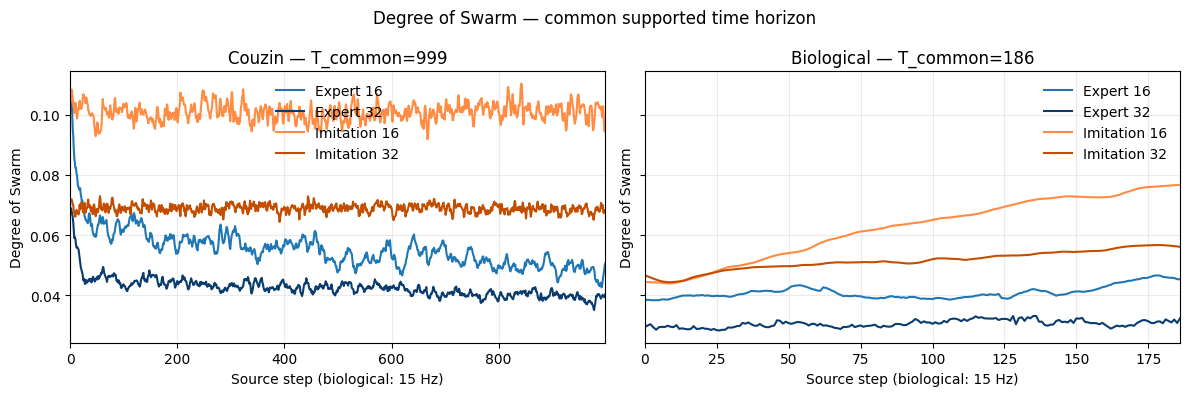

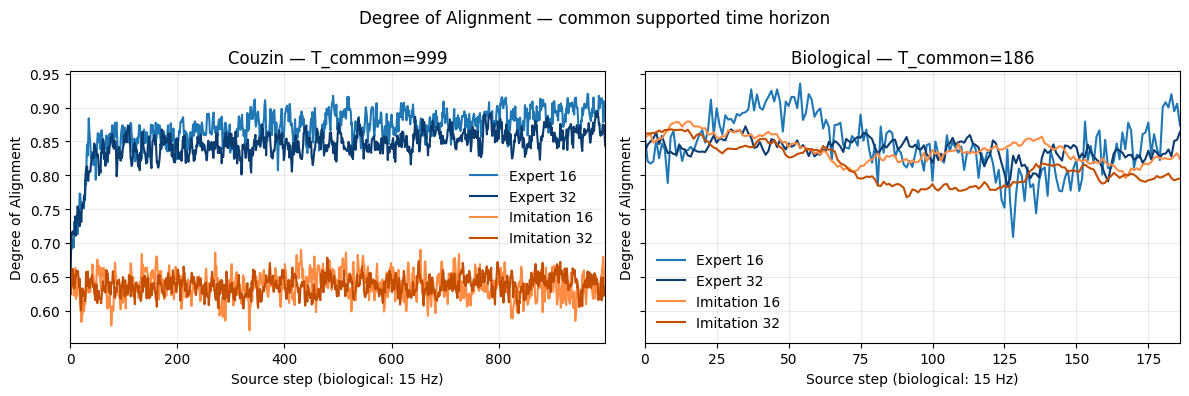

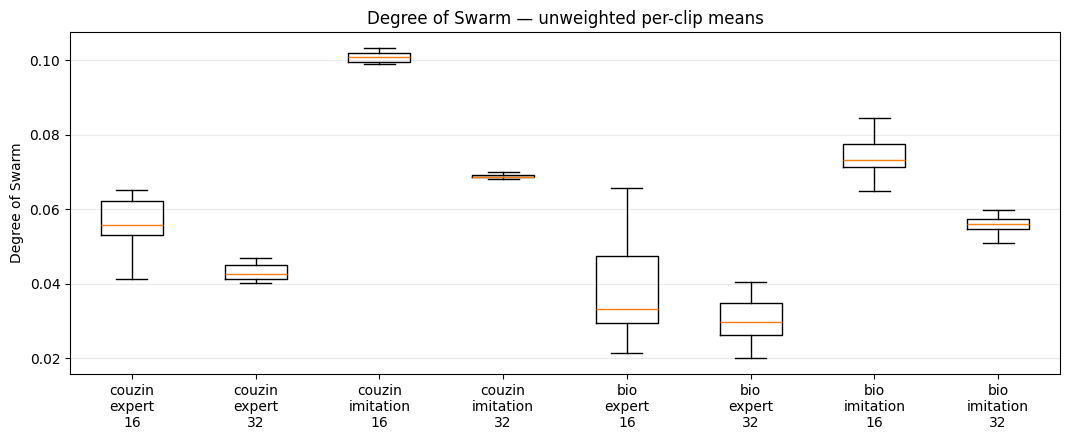

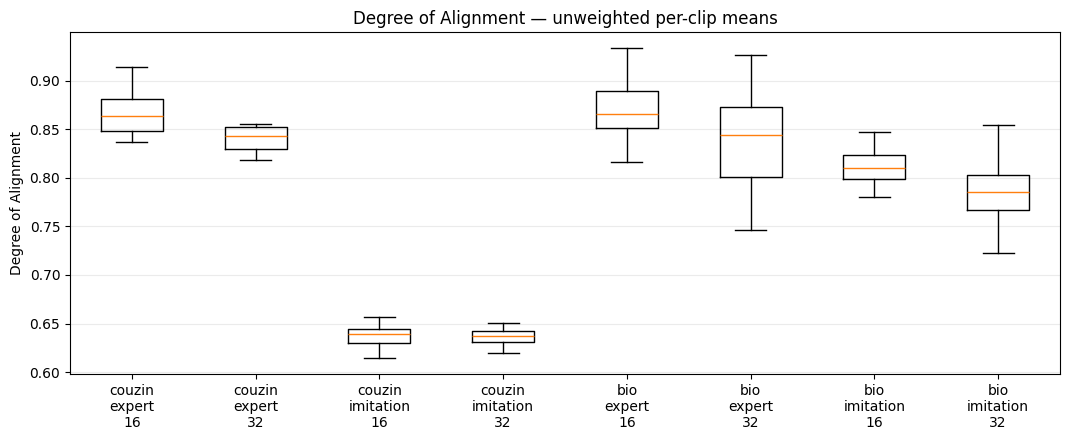

metric,case,clips,mean_of_clip_means,median_clip_mean,q25,q75
dos_timeline,couzin_expert_16,30,0.055419307,0.055586543,0.0531471,0.062173918
dos_timeline,couzin_expert_32,30,0.042554013,0.042610135,0.041302703,0.045128167
dos_timeline,couzin_imitation_16,30,0.10086322,0.10077386,0.099547975,0.10202303
dos_timeline,couzin_imitation_32,30,0.068867974,0.068693392,0.068545856,0.069196671
dos_timeline,bio_expert_16,8,0.039555445,0.03207802,0.029465174,0.047356233
dos_timeline,bio_expert_32,35,0.030262154,0.029845109,0.026278548,0.034882452
dos_timeline,bio_imitation_16,30,0.073987454,0.073070765,0.071417436,0.077426389
dos_timeline,bio_imitation_32,30,0.055601958,0.056058262,0.05461479,0.057418592
doa_timeline,couzin_expert_16,30,0.86950368,0.86218286,0.84860134,0.88065565
doa_timeline,couzin_expert_32,30,0.84522921,0.84250146,0.8294636,0.85189337


In [10]:
def _timeline_matrix(series):
 length=max((len(x) for x in series),default=0)
 matrix=torch.full((len(series),length),torch.nan,device=series[0].device,dtype=series[0].dtype) if length else torch.empty((len(series),0),device=DEVICE)
 for i,x in enumerate(series): matrix[i,:len(x)]=x
 return matrix

common_time_horizon={}; common_time_support_rows=[]; common_time_matrices={}
for key in ('dos_timeline','doa_timeline'):
 common_time_horizon[key]={}; common_time_matrices[key]={}
 for source,names in SOURCE_CASES.items():
  case_last={}; case_info={}
  for name in names:
   if name not in case_results: continue
   matrix=_timeline_matrix(case_results[name][key]); common_time_matrices[key][name]=matrix
   counts=torch.isfinite(matrix).sum(0); required=math.ceil(.5*len(matrix)); supported=counts>=required
   first_failure=torch.nonzero(~supported).flatten(); last=(int(first_failure[0])-1) if len(first_failure) else len(counts)-1
   case_last[name]=last; case_info[name]=(counts,required,len(matrix))
  complete=len(case_last)==len(names) and all(v>=0 for v in case_last.values()); t_common=min(case_last.values()) if complete else None
  common_time_horizon[key][source]=t_common
  for name in names:
   if name not in case_info:
    common_time_support_rows.append({'metric':key,'source':source,'case':name,'original_clips':0,'required_clips_50pct':0,'case_last_supported_step':np.nan,'T_common':np.nan,'clips_at_T_common':0,'support_fraction_at_T_common':np.nan}); continue
   counts,required,n_clips=case_info[name]; at_common=int(counts[t_common]) if t_common is not None else 0
   common_time_support_rows.append({'metric':key,'source':source,'case':name,'original_clips':n_clips,'required_clips_50pct':required,'case_last_supported_step':case_last[name],'T_common':t_common if t_common is not None else np.nan,'clips_at_T_common':at_common,'support_fraction_at_T_common':at_common/n_clips if n_clips else np.nan})
display_table(common_time_support_rows,'Common DoS/DoA time horizon and per-case support')

def plot_common_timeline(key,ylabel):
 fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
 for ax,source in zip(axes,('couzin','biological')):
  stop=common_time_horizon[key][source]
  if stop is None:
   ax.text(.5,.5,'No common supported horizon',ha='center',va='center',transform=ax.transAxes); ax.set_title(source.title()); continue
  for name in SOURCE_CASES[source]:
   matrix=common_time_matrices[key][name][:,:stop+1]; _,style=_style(name)
   ax.plot(torch.arange(stop+1),torch.nanmean(matrix,0).cpu(),color=COLORS[style],label=style.replace('_',' ').title())
  ax.set(title=f'{source.title()} — T_common={stop}',xlabel='Source step (biological: 15 Hz)',ylabel=ylabel,xlim=(0,stop)); ax.grid(alpha=.25); ax.legend(frameon=False)
 fig.suptitle(f'{ylabel} — common supported time horizon'); fig.tight_layout(); plt.show(); plt.close(fig)
plot_common_timeline('dos_timeline','Degree of Swarm')
plot_common_timeline('doa_timeline','Degree of Alignment')

# One unweighted observation per clip: nanmean across that clip's genuine frames only.
per_clip_collective={}; per_clip_collective_rows=[]
def plot_per_clip_collective(key,ylabel):
 names=[]; values=[]; per_clip_collective[key]={}
 for name in case_specs:
  if name not in case_results: continue
  v=torch.stack([torch.nanmean(x.float()) for x in case_results[name][key]]).detach().cpu(); v=v[torch.isfinite(v)]
  per_clip_collective[key][name]=v; names.append(name.replace('_','\n')); values.append(v.numpy())
  per_clip_collective_rows.append({'metric':key,'case':name,'clips':len(v),'mean_of_clip_means':float(v.mean()) if len(v) else np.nan,'median_clip_mean':float(v.median()) if len(v) else np.nan,'q25':float(torch.quantile(v,.25)) if len(v) else np.nan,'q75':float(torch.quantile(v,.75)) if len(v) else np.nan})
 if values:
  fig,ax=plt.subplots(figsize=(max(10,1.35*len(values)),4.5)); ax.boxplot(values,tick_labels=names,showfliers=False); ax.set_ylabel(ylabel); ax.set_title(f'{ylabel} — unweighted per-clip means'); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show(); plt.close(fig)
plot_per_clip_collective('dos_timeline','Degree of Swarm')
plot_per_clip_collective('doa_timeline','Degree of Alignment')
display_table(per_clip_collective_rows,'Unweighted per-clip DoS/DoA distributions')
results['common_time_horizon']={'T_common':common_time_horizon,'support':common_time_support_rows}; results['per_clip_collective_distributions']=per_clip_collective


In [11]:
# Flatten scalar and curve-based group-size results into one readable table.
group_size_summary,group_size_table_rows={},[]
for source,metrics in group_size_results.items():
 group_size_summary[source]={}
 for metric,value in metrics.items():
  item={k:value[k].detach().cpu() for k in ('delta_expert','delta_imitation','consistency_error','valid','fidelity_error_16','fidelity_error_32','valid_fidelity_16','valid_fidelity_32')}; item['MACSE']=float(value['mean_absolute_consistency_error'].detach().cpu()); item['MAFE_16']=float(value['mean_absolute_fidelity_error_16'].detach().cpu()); item['MAFE_32']=float(value['mean_absolute_fidelity_error_32'].detach().cpu()); group_size_summary[source][metric]=item
  de,di,ge=item['delta_expert'].flatten(),item['delta_imitation'].flatten(),item['consistency_error'].flatten()
  valid=item['valid'].flatten(); f16=item['fidelity_error_16'].flatten(); f32=item['fidelity_error_32'].flatten(); vf16=item['valid_fidelity_16'].flatten(); vf32=item['valid_fidelity_32'].flatten()
  for i in range(len(ge)):
   group_size_table_rows.append({'source':source,'metric':metric,'bin':'aggregate' if len(ge)==1 else i,'delta_expert':de[i].item(),'delta_imitation':di[i].item(),'consistency_error':ge[i].item(),'valid_consistency':bool(valid[i]),'fidelity_error_16':f16[i].item(),'valid_fidelity_16':bool(vf16[i]),'fidelity_error_32':f32[i].item(),'valid_fidelity_32':bool(vf32[i]),'MACSE':item['MACSE'],'MAFE_16':item['MAFE_16'],'MAFE_32':item['MAFE_32']})

# Retain the tensor form and display the presentation-oriented rows separately.
numerical_outputs['group_size']=group_size_summary
display_table(group_size_table_rows,'Population-size consistency/sensitivity and imitation fidelity')


source,metric,bin,delta_expert,delta_imitation,consistency_error,valid_consistency,fidelity_error_16,valid_fidelity_16,fidelity_error_32,valid_fidelity_32,MACSE,MAFE_16,MAFE_32
couzin,propagation_time,aggregate,1.079443,1.7254901,0.64604712,True,8.8227787,True,8.1767321,True,0.64604712,8.8227787,8.1767321
couzin,closing_speed,aggregate,-8.7913424e-05,-5.2040778e-06,8.2709346e-05,True,0.00011096596,True,2.8256612e-05,True,8.2709346e-05,0.00011096596,2.8256612e-05
couzin,response_fraction,aggregate,0.015052021,-0.0079330727,-0.022985093,True,0.94835341,True,0.97133851,True,0.022985093,0.94835341,0.97133851
couzin,pursuit_alignment,aggregate,-0.027134955,0.010136638,0.037271593,True,0.86624402,True,0.8289724,True,0.037271593,0.86624402,0.8289724
couzin,polarization_during_approach,aggregate,0.008735504,0.0067493422,-0.0019861618,True,0.066384397,True,0.068370558,True,0.0019861618,0.066384397,0.068370558
couzin,doa,aggregate,-0.024274528,-3.9935112e-05,0.024234593,True,0.23237741,True,0.20814282,True,0.024234593,0.23237741,0.20814282
couzin,reaction_latency_time,aggregate,0.10668969,-0.23891735,-0.34560704,True,2.3765652,True,2.0309582,True,0.34560704,2.3765652,2.0309582
couzin,dos,aggregate,-0.012865301,-0.031995244,-0.019129943,True,0.045443911,True,0.026313968,True,0.019129943,0.045443911,0.026313968
couzin,nnd_during_approach,aggregate,0.0078001469,-0.034780182,-0.042580329,True,0.1427258,True,0.10014547,True,0.042580329,0.1427258,0.10014547
couzin,escape_alignment,aggregate,-0.063330442,0.0030246917,0.066355132,True,0.35102493,True,0.28466982,True,0.066355132,0.35102493,0.28466982


# Video Time-Step Grid

This independent visualization helper extracts six requested frames from a source video. It does not participate in metric calculation and can be rerun without recomputing the analysis results.

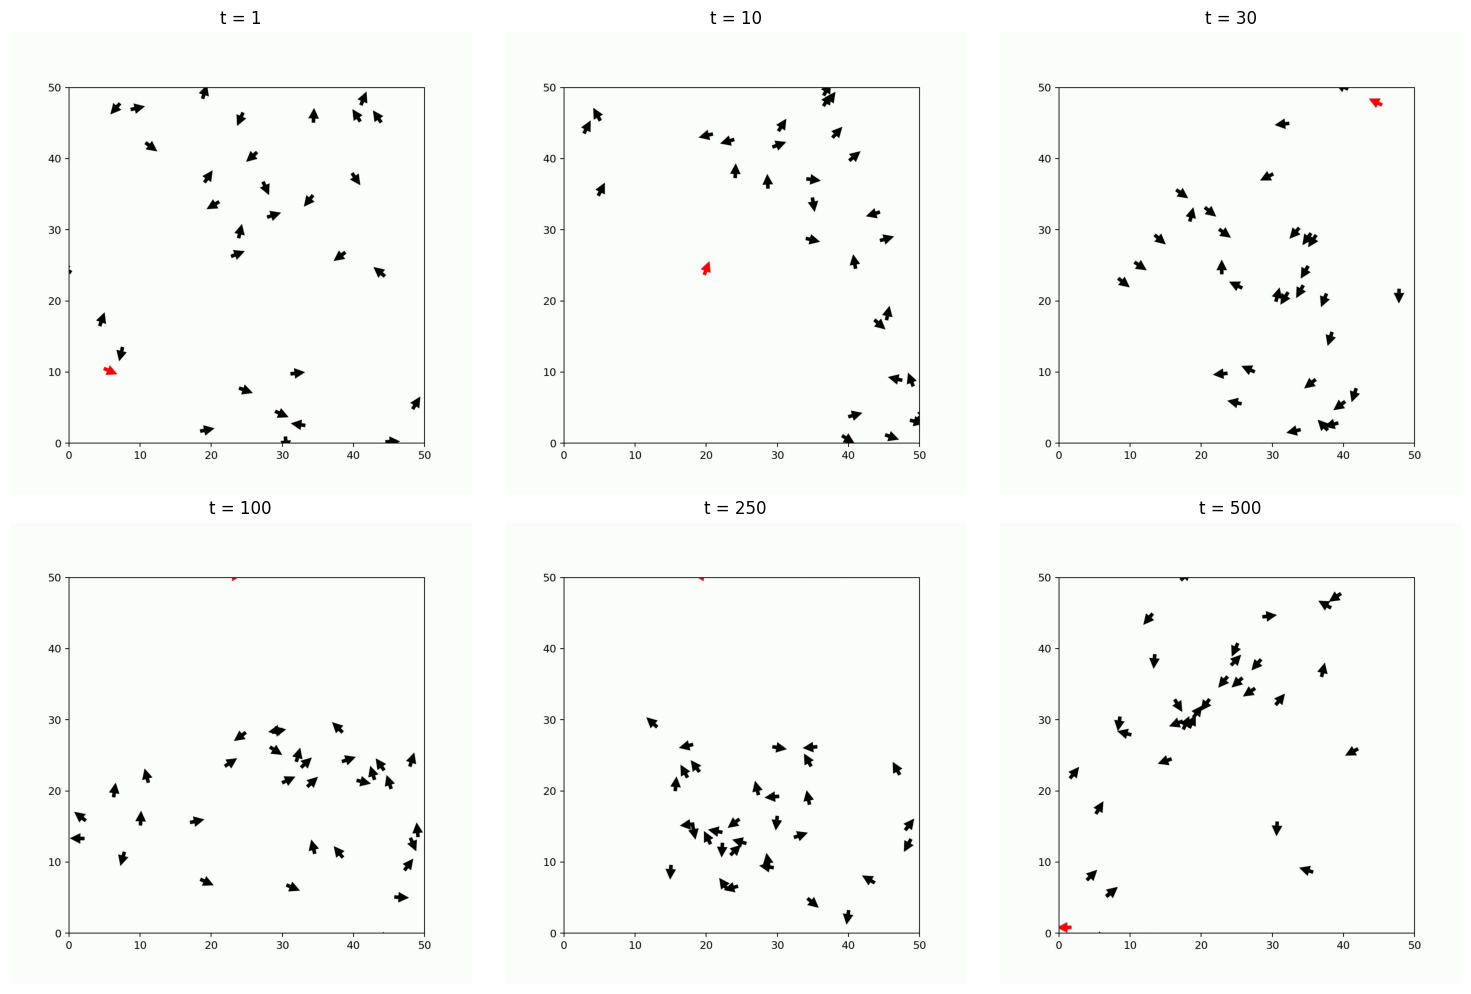

In [12]:
# Read and arrange six requested source frames without loading the full video.
def plot_video_timesteps(video_path,timesteps,*,title='',figsize=(15,10),clip_out_of_range=True):
 import cv2
 video_path=Path(video_path).resolve(); timesteps=list(timesteps)
 if len(timesteps)!=6: raise ValueError('Exactly six timesteps are required')
 cap=cv2.VideoCapture(str(video_path))
 if not cap.isOpened(): raise RuntimeError(f'Could not open {video_path}')
 count=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); requested=np.asarray(timesteps,dtype=int)
 if (requested>=count).any() and not clip_out_of_range: cap.release(); raise IndexError('Timestep exceeds video length')
 frames=np.clip(requested,0,count-1); fig,axes=plt.subplots(2,3,figsize=figsize)

 # Seek directly to each frame and release the video handle even if reading fails.
 try:
  for ax,t,frame in zip(axes.flat,requested,frames):
   cap.set(cv2.CAP_PROP_POS_FRAMES,int(frame)); ok,image=cap.read()
   if not ok: raise RuntimeError(f'Could not read frame {frame}')
   ax.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB)); ax.set_title(f't = {t}'); ax.axis('off')
 finally: cap.release()
 if title: fig.suptitle(title)
 fig.tight_layout(); return fig,axes

# Example grid used in the paper-analysis workflow.
VIDEO_PATH = PROJECT_ROOT / 'assets' / 'videos' / 'couzin.mp4'
video_grid_fig,video_grid_axes=plot_video_timesteps(VIDEO_PATH,[1,10,30,100,250,500]); plt.show(); plt.close(video_grid_fig)


# Analysis of Modular Networks — Biological vs Couzin Policies

This reuses Jannik's Pairwise-Interaction/Attention analysis without modifying his repository.

## Analysis setup

The current checkpoints include an additional active-mask feature, which is appended automatically. Each map is evaluated on the same relative-position grid and averaged over uniformly sampled relative-velocity orientations. This keeps the Biological and Couzin results directly comparable.

## Visual interpretation

The Pairwise-Interaction maps show the directional action produced for a neighbor at each relative position. The Attention maps show which relative positions receive stronger or weaker attention.

The original `inferno` (PIN) and `RdBu` (attention) color schemes are retained. Shared color scales are used across both policies so visual differences reflect model differences rather than separate rescaling. The focal agent is shown at the origin in every map: a predator icon for predator maps and a prey icon for prey and preyâ€“predator maps.

In [13]:
from matplotlib import colors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Resolution and batching follow the original map construction while keeping GPU memory bounded.
MODULAR_GRID_SIZE, MODULAR_ORIENTATIONS, MODULAR_BATCH_SIZE = 100, 100, 65536

# Load independent policy pairs for the Couzin-trained and biologically trained models.
modular_policy_pairs = {
 'Couzin': pa.load_policy_pair(COUZIN_POLICY, COUZIN_POLICY['root']),
 'Biological': pa.load_policy_pair(BIO_POLICY, BIO_POLICY['root']),
}

# Prepare one result slot and one task for every policy/interaction perspective.
modular_network_results = {name:{} for name in modular_policy_pairs}
modular_tasks = [(name,role) for name in modular_policy_pairs for role in ('predator','prey','prey_pred')]

# Compute all maps once; predator and prey policies are selected according to the role.
for policy_name,role in tqdm(modular_tasks,desc='Computing modular-network maps'):
 prey_policy,predator_policy = modular_policy_pairs[policy_name]
 policy = predator_policy if role == 'predator' else prey_policy
 modular_network_results[policy_name][role] = pa.compute_modular_network_maps(
  policy,role=role,grid_size=MODULAR_GRID_SIZE,n_orientations=MODULAR_ORIENTATIONS,
  batch_size=MODULAR_BATCH_SIZE,device=DEVICE)


Computing modular-network maps: 100%|██████████| 6/6 [00:00<00:00, 14.41it/s]


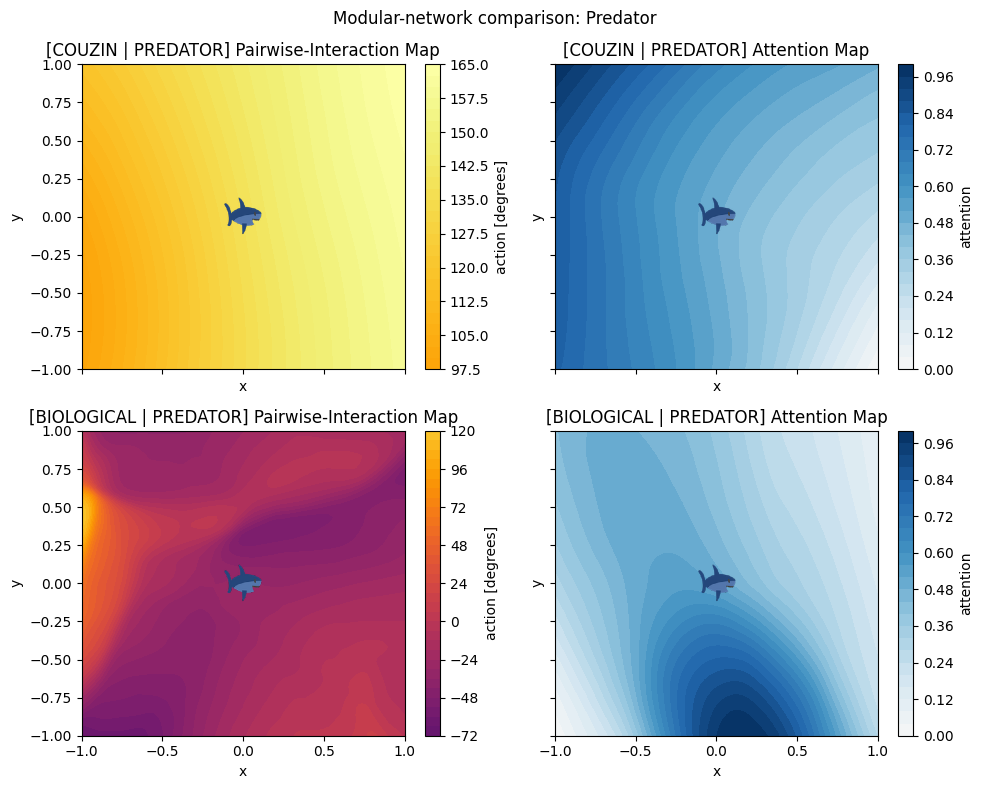

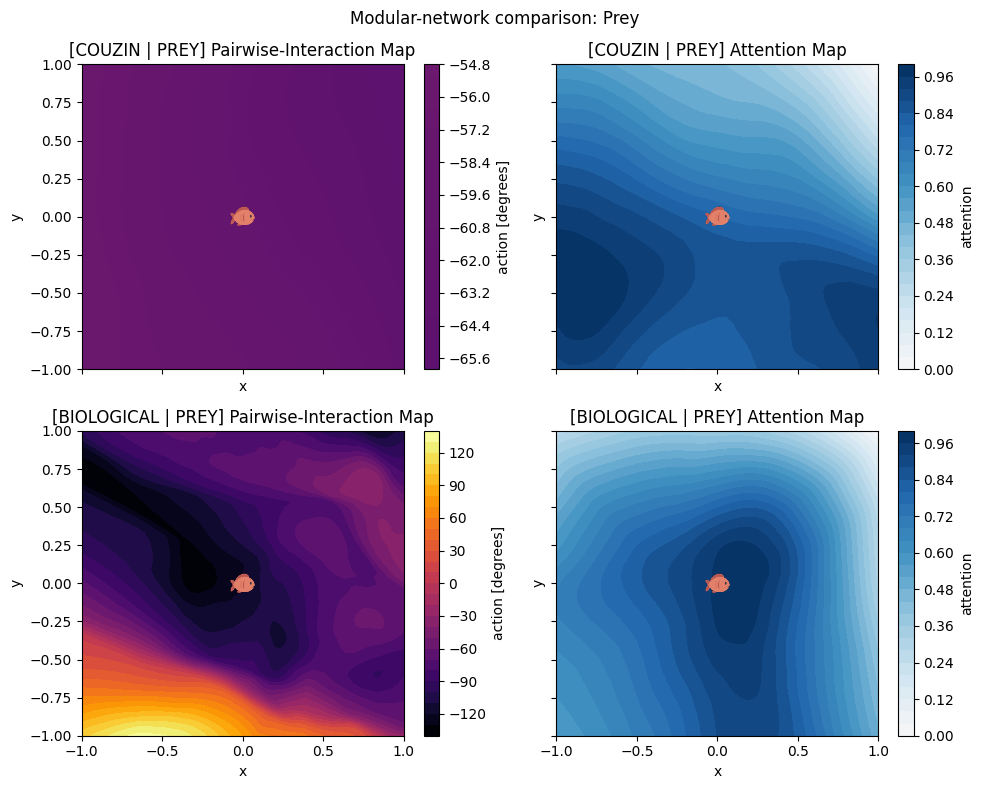

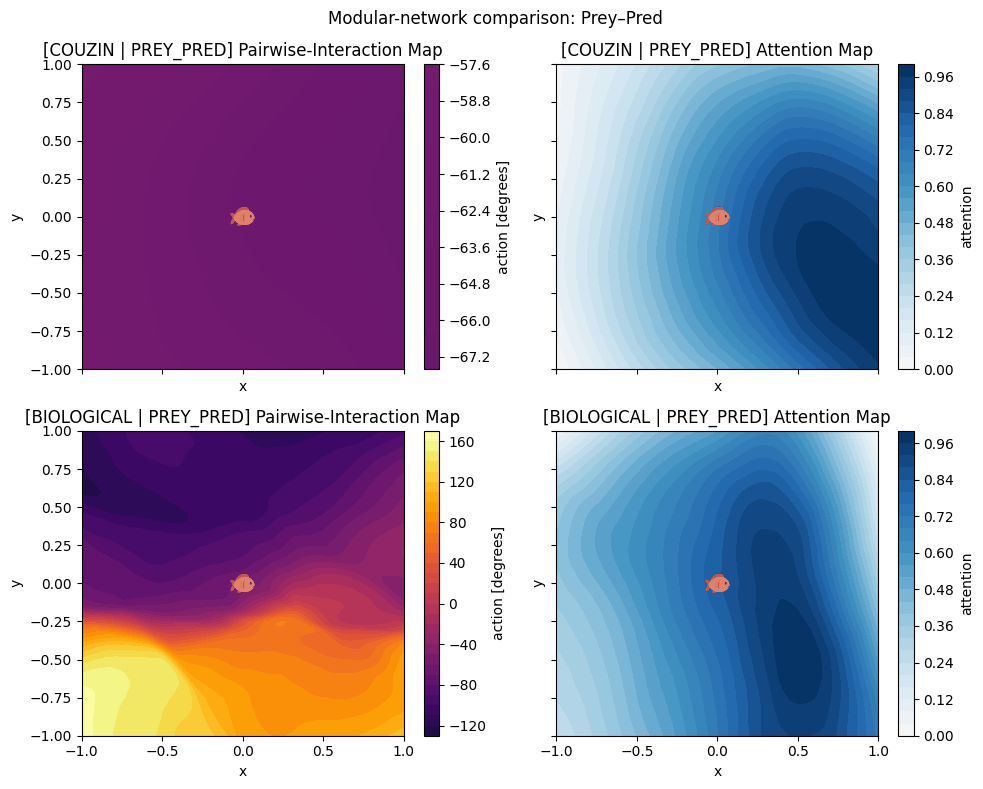

role,module,couzin_mean,biological_mean,mean_difference,MAE,RMSE,max_abs_difference,correlation
predator,Pairwise interaction,136.06883,-18.052977,-154.12183,154.15097,157.56104,215.90279,-0.1937017
predator,Attention,0.53849471,0.43843883,-0.10005593,0.23859817,0.28841427,0.81113774,0.021077471
prey,Pairwise interaction,-60.220207,-61.703457,-1.4832559,42.175598,57.172699,190.3203,0.23196049
prey,Attention,0.73429734,0.68791956,-0.04637783,0.14987871,0.18531665,0.53191161,0.59202403
prey_pred,Pairwise interaction,-62.893394,-12.384338,50.509052,78.791054,102.28627,226.03267,0.022071593
prey_pred,Attention,0.55714118,0.64078838,0.083647177,0.18097854,0.20716955,0.58667529,0.7473821


In [14]:
# Agent icons mirror the visual convention used in Jannik's experiment plots.
MODULAR_ICON_PATHS = {
 'predator': ANALYSIS_DIR/'images/predator.png',
 'prey': ANALYSIS_DIR/'images/prey.png',
 'prey_pred': ANALYSIS_DIR/'images/prey.png',
}

# Plot Couzin and Biological maps with a shared scale for one interaction perspective.
def plot_modular_network_comparison(role):
 policy_order=('Couzin','Biological'); action_maps=[modular_network_results[p][role]['action']*180 for p in policy_order]; attention_maps=[modular_network_results[p][role]['attention'] for p in policy_order]
 icon=plt.imread(MODULAR_ICON_PATHS[role])

 # Shared limits prevent policy-specific color normalization from hiding differences.
 vmax_action=max(float(m.abs().max()) for m in action_maps) or 1.0; vmax_attention=max(float(m.abs().max()) for m in attention_maps) or 1.0
 action_norm=colors.TwoSlopeNorm(vcenter=0,vmin=-vmax_action,vmax=vmax_action); attention_norm=colors.TwoSlopeNorm(vcenter=0,vmin=-vmax_attention,vmax=vmax_attention)

 # Couzin occupies the first row and Biological the second; modules form the columns.
 fig,axes=plt.subplots(2,2,figsize=(10,8),sharex=True,sharey=True)
 for row,policy_name in enumerate(policy_order):
  result=modular_network_results[policy_name][role]; x,y=np.meshgrid(result['x'].numpy(),result['y'].numpy())
  im_action=axes[row,0].contourf(x,y,action_maps[row].numpy(),levels=30,cmap='inferno',norm=action_norm)
  im_attention=axes[row,1].contourf(x,y,attention_maps[row].numpy(),levels=30,cmap='RdBu',norm=attention_norm)
  axes[row,0].set_title(f'[{policy_name.upper()} | {role.upper()}] Pairwise-Interaction Map'); axes[row,1].set_title(f'[{policy_name.upper()} | {role.upper()}] Attention Map')
  for ax in axes[row]:
   ax.set(xlabel='x',ylabel='y',xlim=(result['x'].min(),result['x'].max()),ylim=(result['y'].min(),result['y'].max()))
   ax.add_artist(AnnotationBbox(OffsetImage(icon,zoom=.45),(0,0),frameon=False,xycoords='data',zorder=5))
  fig.colorbar(im_action,ax=axes[row,0],label='action [degrees]'); fig.colorbar(im_attention,ax=axes[row,1],label='attention')
 fig.suptitle(f'Modular-network comparison: {role.replace("_","–").title()}'); fig.tight_layout(); plt.show(); plt.close(fig); return fig

# Generate one figure for Predator, Prey–Prey, and Prey–Predator interactions.
modular_network_figures = {role:plot_modular_network_comparison(role) for role in ('predator','prey','prey_pred')}

# Complement the visual maps with direct numerical differences between both policy families.
comparison_rows=[]; modular_network_comparison={}
for role in ('predator','prey','prey_pred'):
 modular_network_comparison[role]={}
 for module,key,scale in (('Pairwise interaction','action',180.0),('Attention','attention',1.0)):
  couzin=modular_network_results['Couzin'][role][key].float().flatten()*scale; biological=modular_network_results['Biological'][role][key].float().flatten()*scale; difference=biological-couzin
  correlation=float(torch.corrcoef(torch.stack((couzin,biological)))[0,1]) if couzin.std()>0 and biological.std()>0 else np.nan
  values={'couzin_mean':float(couzin.mean()),'biological_mean':float(biological.mean()),'mean_difference':float(difference.mean()),'MAE':float(difference.abs().mean()),'RMSE':float(difference.square().mean().sqrt()),'max_abs_difference':float(difference.abs().max()),'correlation':correlation}
  modular_network_comparison[role][key]=values; comparison_rows.append({'role':role,'module':module,**values})

# Retain maps and summaries for later figures, tables, or optional serialization.
results['modular_networks']=modular_network_results; numerical_outputs['modular_network_comparison']=modular_network_comparison
display_table(comparison_rows,'Biological versus Couzin modular-network comparison')
if SAVE_RESULTS: torch.save(results,OUTPUT_DIR/'predator_prey_metrics.pt')
